In [ ]:
!pip install -q xgboost keras-tcn tensorflow scikit-learn>=1.5 matplotlib pandas seaborn

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tcn import TCN
import xgboost as xgb

In [ ]:
from google.colab import files
uploaded = files.upload()
path = list(uploaded.keys())[0]

df = pd.read_csv(path, parse_dates=['Date and Hour'])
print("Shape:", df.shape)
df.head()


Saving wind_solar.csv to wind_solar.csv
Shape: (59806, 9)


,Date and Hour,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName
0,2020-07-22 20:00:00+02:00,22-07-2020,20:00:00,21:00:00,Solar,244.0,204,Wednesday,July
1,2020-07-23 07:00:00+02:00,23-07-2020,07:00:00,08:00:00,Solar,223.0,205,Thursday,July
2,2020-07-23 16:00:00+02:00,23-07-2020,16:00:00,17:00:00,Solar,2517.0,205,Thursday,July
3,2020-07-23 19:00:00+02:00,23-07-2020,19:00:00,20:00:00,Solar,658.0,205,Thursday,July
4,2020-07-23 23:00:00+02:00,23-07-2020,23:00:00,24:00:00,Solar,0.0,205,Thursday,July


In [ ]:
solar_df = df[df['Source'] == 'Solar'].copy()
print("Shape of Solar Data:", solar_df.shape)
display(solar_df.head())

Shape of Solar Data: (29902, 9)


,Date and Hour,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName
0,2020-07-22 20:00:00+02:00,22-07-2020,20:00:00,21:00:00,Solar,244.0,204,Wednesday,July
1,2020-07-23 07:00:00+02:00,23-07-2020,07:00:00,08:00:00,Solar,223.0,205,Thursday,July
2,2020-07-23 16:00:00+02:00,23-07-2020,16:00:00,17:00:00,Solar,2517.0,205,Thursday,July
3,2020-07-23 19:00:00+02:00,23-07-2020,19:00:00,20:00:00,Solar,658.0,205,Thursday,July
4,2020-07-23 23:00:00+02:00,23-07-2020,23:00:00,24:00:00,Solar,0.0,205,Thursday,July


Missing values per column:
Date and Hour    0
Date             0
StartHour        0
EndHour          0
Source           0
Production       1
dayOfYear        0
dayName          0
monthName        0
dtype: int64


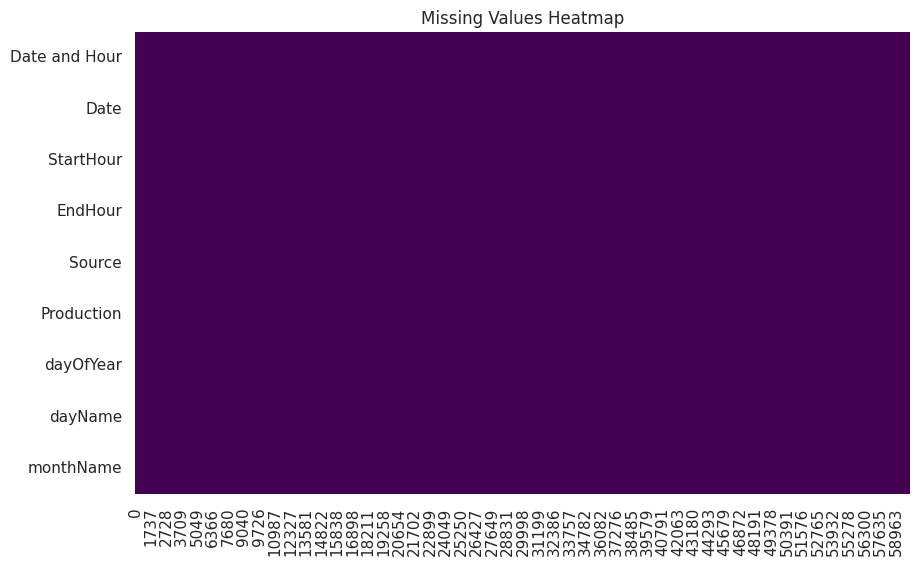

In [ ]:
missing_values = solar_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

plt.figure(figsize=(10, 6))
sns.heatmap(solar_df.isnull().T, cmap='viridis', cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
mean_production = solar_df['Production'].mean()
solar_df['Production'].fillna(mean_production, inplace=True)
missing_values_after_fill = solar_df.isnull().sum()
print("Missing values per column after filling:")
print(missing_values_after_fill)

Missing values per column after filling:
Date and Hour    0
Date             0
StartHour        0
EndHour          0
Source           0
Production       0
dayOfYear        0
dayName          0
monthName        0
dtype: int64


/tmp/ipython-input-2994567980.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  solar_df['Production'].fillna(mean_production, inplace=True)


In [ ]:
duplicate_rows = solar_df.duplicated().sum()
print(f"Number of duplicate rows in solar_df: {duplicate_rows}")

Number of duplicate rows in solar_df: 0


In [ ]:
print(solar_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29902 entries, 0 to 59805
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date and Hour  29902 non-null  object 
 1   Date           29902 non-null  object 
 2   StartHour      29902 non-null  object 
 3   EndHour        29902 non-null  object 
 4   Source         29902 non-null  object 
 5   Production     29902 non-null  float64
 6   dayOfYear      29902 non-null  int64  
 7   dayName        29902 non-null  object 
 8   monthName      29902 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.3+ MB
None


In [ ]:
solar_df_cleaned = df[df['Source'] == 'Solar'].copy()

solar_df_cleaned['Date and Hour'] = pd.to_datetime(solar_df_cleaned['Date and Hour'], utc=True)
solar_df_cleaned['Date'] = pd.to_datetime(solar_df_cleaned['Date'], dayfirst=True)

solar_df_cleaned['StartHour_str'] = solar_df_cleaned['StartHour'].astype(str).replace('24:00:00', '00:00:00')
solar_df_cleaned['EndHour_str'] = solar_df_cleaned['EndHour'].astype(str).replace('24:00:00', '00:00:00')

solar_df_cleaned['StartHour'] = pd.to_datetime(solar_df_cleaned['StartHour_str']).dt.time
solar_df_cleaned['EndHour'] = pd.to_datetime(solar_df_cleaned['EndHour_str']).dt.time

# Drop the temporary string columns
solar_df_cleaned = solar_df_cleaned.drop(columns=['StartHour_str', 'EndHour_str'])

solar_df_cleaned['Source'] = solar_df_cleaned['Source'].astype('category')
solar_df_cleaned['dayName'] = solar_df_cleaned['dayName'].astype('category')
solar_df_cleaned['monthName'] = solar_df_cleaned['monthName'].astype('category')

# Replace the original solar_df with the cleaned one
solar_df = solar_df_cleaned

print(solar_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29902 entries, 0 to 59805
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Date and Hour  29902 non-null  datetime64[ns, UTC]
 1   Date           29902 non-null  datetime64[ns]     
 2   StartHour      29902 non-null  object             
 3   EndHour        29902 non-null  object             
 4   Source         29902 non-null  category           
 5   Production     29901 non-null  float64            
 6   dayOfYear      29902 non-null  int64              
 7   dayName        29902 non-null  category           
 8   monthName      29902 non-null  category           
dtypes: category(3), datetime64[ns, UTC](1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.7+ MB
None


/tmp/ipython-input-1413898568.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  solar_df_cleaned['StartHour'] = pd.to_datetime(solar_df_cleaned['StartHour_str']).dt.time
/tmp/ipython-input-1413898568.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  solar_df_cleaned['EndHour'] = pd.to_datetime(solar_df_cleaned['EndHour_str']).dt.time


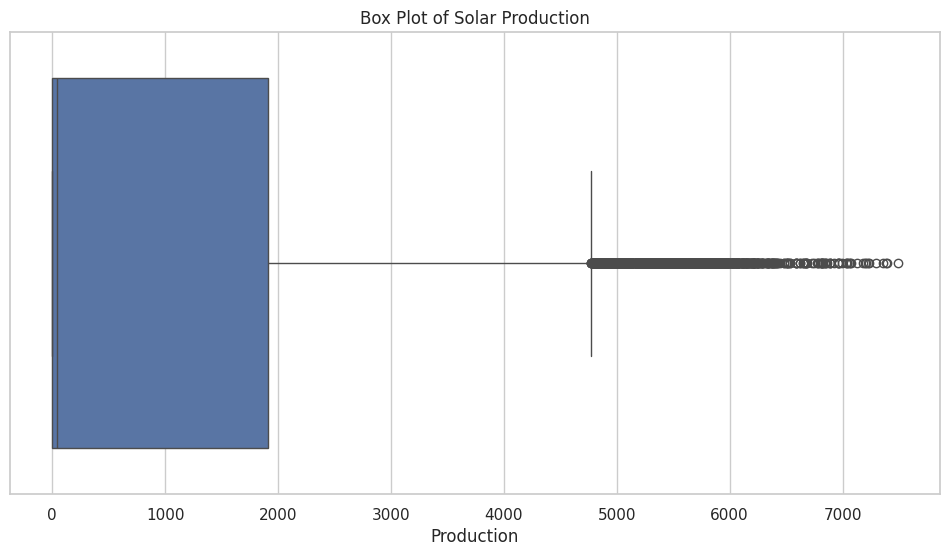

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=solar_df['Production'])
plt.title('Box Plot of Solar Production')
plt.xlabel('Production')
plt.show()

Q1: 1.0
Q3: 1909.0
IQR: 1908.0
Lower Bound (Outlier Threshold): -2861.0
Upper Bound (Outlier Threshold): 4771.0

Production column statistics before and after outlier handling:
Before:
count    29901.000000
mean      1068.862379
std       1547.220727
min          0.000000
25%          1.000000
50%         42.000000
75%       1909.000000
max       7489.000000
Name: Production, dtype: float64

After (capped):
count    29901.000000
mean      1041.849135
std       1470.327470
min          0.000000
25%          1.000000
50%         42.000000
75%       1909.000000
max       4771.000000
Name: Production_cleaned, dtype: float64


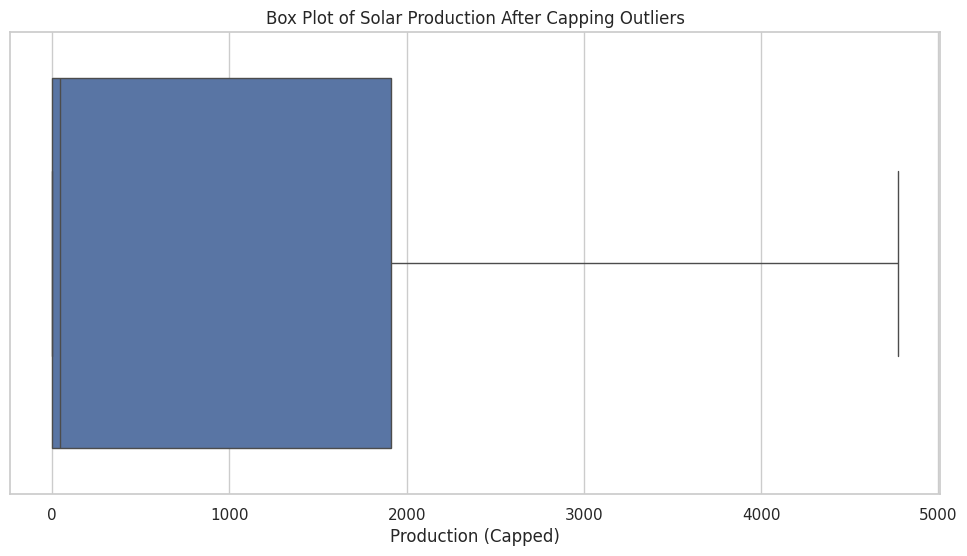

In [ ]:
Q1 = solar_df['Production'].quantile(0.25)
Q3 = solar_df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound (Outlier Threshold): {lower_bound}")
print(f"Upper Bound (Outlier Threshold): {upper_bound}")

# Cap the outliers
solar_df['Production_cleaned'] = solar_df['Production'].clip(lower=lower_bound, upper=upper_bound)

print("\nProduction column statistics before and after outlier handling:")
print("Before:")
print(solar_df['Production'].describe())
print("\nAfter (capped):")
print(solar_df['Production_cleaned'].describe())

# Optional: Visualize the distribution after capping
plt.figure(figsize=(12, 6))
sns.boxplot(x=solar_df['Production_cleaned'])
plt.title('Box Plot of Solar Production After Capping Outliers')
plt.xlabel('Production (Capped)')
plt.show()

In [ ]:
wind_df = df[df['Source'] == 'Wind'].copy()
print("Shape of Wind Data:", wind_df.shape)
display(wind_df.head())

Shape of Wind Data: (29904, 9)


,Date and Hour,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName
45,2020-08-01 02:00:00+02:00,01-08-2020,02:00:00,03:00:00,Wind,2073.0,214,Saturday,August
46,2020-08-01 06:00:00+02:00,01-08-2020,06:00:00,07:00:00,Wind,1742.0,214,Saturday,August
47,2020-08-01 13:00:00+02:00,01-08-2020,13:00:00,14:00:00,Wind,1185.0,214,Saturday,August
48,2020-08-01 14:00:00+02:00,01-08-2020,14:00:00,15:00:00,Wind,1544.0,214,Saturday,August
49,2020-08-01 19:00:00+02:00,01-08-2020,19:00:00,20:00:00,Wind,3919.0,214,Saturday,August


Missing values per column in wind_df:
Date and Hour    0
Date             0
StartHour        0
EndHour          0
Source           0
Production       1
dayOfYear        0
dayName          0
monthName        0
dtype: int64


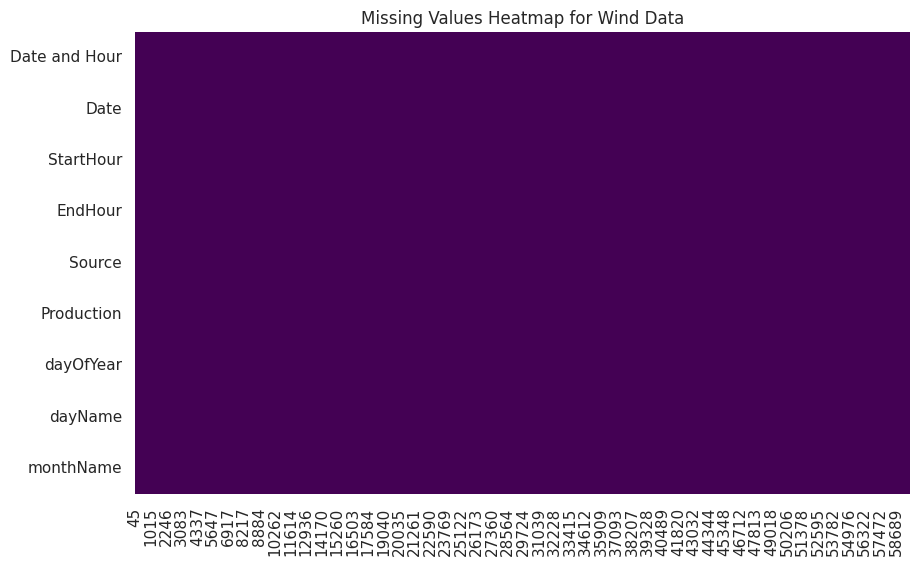

In [ ]:
missing_values_wind = wind_df.isnull().sum()
print("Missing values per column in wind_df:")
print(missing_values_wind)

plt.figure(figsize=(10, 6))
sns.heatmap(wind_df.isnull().T, cmap='viridis', cbar=False)
plt.title('Missing Values Heatmap for Wind Data')
plt.show()

In [ ]:
mean_production_wind = wind_df['Production'].mean()
wind_df['Production'].fillna(mean_production_wind, inplace=True)
missing_values_after_fill_wind = wind_df.isnull().sum()
print("Missing values per column after filling in wind_df:")
print(missing_values_after_fill_wind)

Missing values per column after filling in wind_df:
Date and Hour    0
Date             0
StartHour        0
EndHour          0
Source           0
Production       0
dayOfYear        0
dayName          0
monthName        0
dtype: int64


/tmp/ipython-input-799680632.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  wind_df['Production'].fillna(mean_production_wind, inplace=True)


In [ ]:
duplicate_rows_wind = wind_df.duplicated().sum()
print(f"Number of duplicate rows in wind_df: {duplicate_rows_wind}")

Number of duplicate rows in wind_df: 0


In [ ]:
print(wind_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29904 entries, 45 to 59671
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date and Hour  29904 non-null  object 
 1   Date           29904 non-null  object 
 2   StartHour      29904 non-null  object 
 3   EndHour        29904 non-null  object 
 4   Source         29904 non-null  object 
 5   Production     29904 non-null  float64
 6   dayOfYear      29904 non-null  int64  
 7   dayName        29904 non-null  object 
 8   monthName      29904 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.3+ MB
None


In [ ]:
wind_df_cleaned = wind_df.copy()

wind_df_cleaned['Date and Hour'] = pd.to_datetime(wind_df_cleaned['Date and Hour'], utc=True)
wind_df_cleaned['Date'] = pd.to_datetime(wind_df_cleaned['Date'], dayfirst=True)

wind_df_cleaned['StartHour_str'] = wind_df_cleaned['StartHour'].astype(str).replace('24:00:00', '00:00:00')
wind_df_cleaned['EndHour_str'] = wind_df_cleaned['EndHour'].astype(str).replace('24:00:00', '00:00:00')

wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour_str']).dt.time
wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour_str']).dt.time

# Drop the temporary string columns
wind_df_cleaned = wind_df_cleaned.drop(columns=['StartHour_str', 'EndHour_str'])


wind_df_cleaned['Source'] = wind_df_cleaned['Source'].astype('category')
wind_df_cleaned['dayName'] = wind_df_cleaned['dayName'].astype('category')
wind_df_cleaned['monthName'] = wind_df_cleaned['monthName'].astype('category')

# Replace the original wind_df with the cleaned one
wind_df = wind_df_cleaned

print(wind_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29904 entries, 45 to 59671
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Date and Hour  29904 non-null  datetime64[ns, UTC]
 1   Date           29904 non-null  datetime64[ns]     
 2   StartHour      29904 non-null  object             
 3   EndHour        29904 non-null  object             
 4   Source         29904 non-null  category           
 5   Production     29904 non-null  float64            
 6   dayOfYear      29904 non-null  int64              
 7   dayName        29904 non-null  category           
 8   monthName      29904 non-null  category           
dtypes: category(3), datetime64[ns, UTC](1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 2.7+ MB
None


/tmp/ipython-input-3097755556.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour_str']).dt.time
/tmp/ipython-input-3097755556.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour_str']).dt.time


In [ ]:
wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour'].astype(str).replace('24:00:00', '00:00:00')).dt.time
wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour'].astype(str).replace('24:00:00', '00:00:00')).dt.time

wind_df = wind_df_cleaned

print(wind_df.info())

/tmp/ipython-input-1936123493.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour'].astype(str).replace('24:00:00', '00:00:00')).dt.time


<class 'pandas.core.frame.DataFrame'>
Index: 29904 entries, 45 to 59671
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Date and Hour  29904 non-null  datetime64[ns, UTC]
 1   Date           29904 non-null  datetime64[ns]     
 2   StartHour      29904 non-null  object             
 3   EndHour        29904 non-null  object             
 4   Source         29904 non-null  category           
 5   Production     29904 non-null  float64            
 6   dayOfYear      29904 non-null  int64              
 7   dayName        29904 non-null  category           
 8   monthName      29904 non-null  category           
dtypes: category(3), datetime64[ns, UTC](1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 2.7+ MB
None


/tmp/ipython-input-1936123493.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour'].astype(str).replace('24:00:00', '00:00:00')).dt.time


In [ ]:
wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour'].astype(str).replace('24:00:00', '00:00:00'), format='%H:%M:%S').dt.time
wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour'].astype(str).replace('24:00:00', '00:00:00'), format='%H:%M:%S').dt.time

wind_df = wind_df_cleaned

print(wind_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29904 entries, 45 to 59671
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Date and Hour  29904 non-null  datetime64[ns, UTC]
 1   Date           29904 non-null  datetime64[ns]     
 2   StartHour      29904 non-null  object             
 3   EndHour        29904 non-null  object             
 4   Source         29904 non-null  category           
 5   Production     29904 non-null  float64            
 6   dayOfYear      29904 non-null  int64              
 7   dayName        29904 non-null  category           
 8   monthName      29904 non-null  category           
dtypes: category(3), datetime64[ns, UTC](1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 2.7+ MB
None


In [ ]:
# Convert 'StartHour' and 'EndHour' to datetime objects with a dummy date and extract time
wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour'].astype(str).replace('24:00:00', '00:00:00'), format='%H:%M:%S').dt.time
wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour'].astype(str).replace('24:00:00', '00:00:00'), format='%H:%M:%S').dt.time

# Replace the original wind_df with the cleaned one
wind_df = wind_df_cleaned

print(wind_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29904 entries, 45 to 59671
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Date and Hour  29904 non-null  datetime64[ns, UTC]
 1   Date           29904 non-null  datetime64[ns]     
 2   StartHour      29904 non-null  object             
 3   EndHour        29904 non-null  object             
 4   Source         29904 non-null  category           
 5   Production     29904 non-null  float64            
 6   dayOfYear      29904 non-null  int64              
 7   dayName        29904 non-null  category           
 8   monthName      29904 non-null  category           
dtypes: category(3), datetime64[ns, UTC](1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 2.7+ MB
None


In [ ]:
wind_df_cleaned['StartHour'] = pd.to_timedelta(wind_df_cleaned['StartHour'].astype(str).str.replace('24:00:00', '00:00:00')).dt.components.hours.apply(lambda x: f'{x:02d}:00:00')
wind_df_cleaned['EndHour'] = pd.to_timedelta(wind_df_cleaned['EndHour'].astype(str).str.replace('24:00:00', '00:00:00')).dt.components.hours.apply(lambda x: f'{x:02d}:00:00')

wind_df_cleaned['StartHour'] = pd.to_datetime(wind_df_cleaned['StartHour'], format='%H:%M:%S').dt.time
wind_df_cleaned['EndHour'] = pd.to_datetime(wind_df_cleaned['EndHour'], format='%H:%M:%S').dt.time

# Replace the original wind_df with the cleaned one
wind_df = wind_df_cleaned

print(wind_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29904 entries, 45 to 59671
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Date and Hour  29904 non-null  datetime64[ns, UTC]
 1   Date           29904 non-null  datetime64[ns]     
 2   StartHour      29904 non-null  object             
 3   EndHour        29904 non-null  object             
 4   Source         29904 non-null  category           
 5   Production     29904 non-null  float64            
 6   dayOfYear      29904 non-null  int64              
 7   dayName        29904 non-null  category           
 8   monthName      29904 non-null  category           
dtypes: category(3), datetime64[ns, UTC](1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 2.7+ MB
None


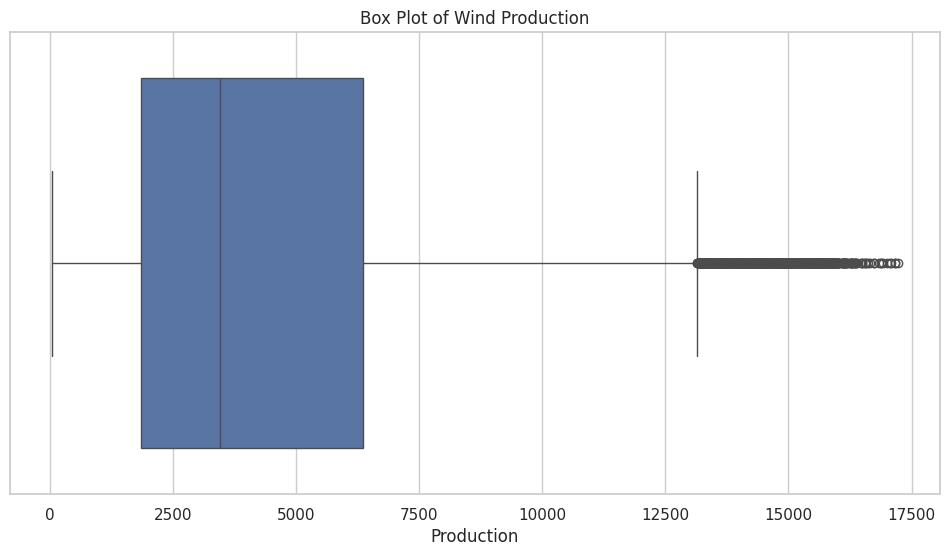

Q1 (Wind): 1847.0
Q3 (Wind): 6364.25
IQR (Wind): 4517.25
Lower Bound (Outlier Threshold - Wind): -4928.875
Upper Bound (Outlier Threshold - Wind): 13140.125

Wind Production column statistics before and after outlier handling:
Before:
count    29904.000000
mean      4516.741865
std       3466.531871
min         42.000000
25%       1847.000000
50%       3451.500000
75%       6364.250000
max      17220.000000
Name: Production, dtype: float64

After (capped):
count    29904.000000
mean      4478.096847
std       3357.074025
min         42.000000
25%       1847.000000
50%       3451.500000
75%       6364.250000
max      13140.125000
Name: Production_cleaned, dtype: float64


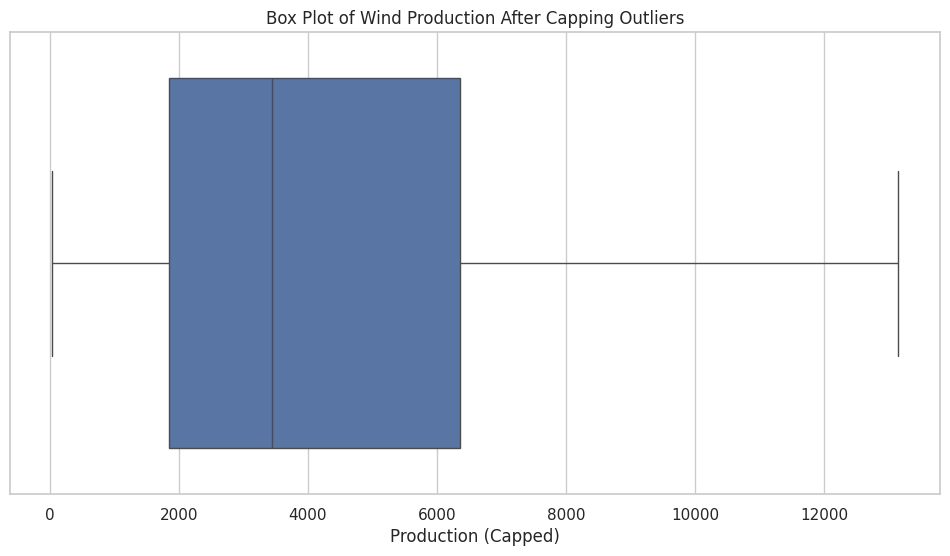

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=wind_df['Production'])
plt.title('Box Plot of Wind Production')
plt.xlabel('Production')
plt.show()

Q1_wind = wind_df['Production'].quantile(0.25)
Q3_wind = wind_df['Production'].quantile(0.75)
IQR_wind = Q3_wind - Q1_wind

lower_bound_wind = Q1_wind - 1.5 * IQR_wind
upper_bound_wind = Q3_wind + 1.5 * IQR_wind

print(f"Q1 (Wind): {Q1_wind}")
print(f"Q3 (Wind): {Q3_wind}")
print(f"IQR (Wind): {IQR_wind}")
print(f"Lower Bound (Outlier Threshold - Wind): {lower_bound_wind}")
print(f"Upper Bound (Outlier Threshold - Wind): {upper_bound_wind}")

wind_df['Production_cleaned'] = wind_df['Production'].clip(lower=lower_bound_wind, upper=upper_bound_wind)

print("\nWind Production column statistics before and after outlier handling:")
print("Before:")
print(wind_df['Production'].describe())
print("\nAfter (capped):")
print(wind_df['Production_cleaned'].describe())

plt.figure(figsize=(12, 6))
sns.boxplot(x=wind_df['Production_cleaned'])
plt.title('Box Plot of Wind Production After Capping Outliers')
plt.xlabel('Production (Capped)')
plt.show()

In [ ]:

df = pd.read_csv(path, parse_dates=['Date and Hour'])

# Ensure 'Date and Hour' is the index for merging
df = df.set_index('Date and Hour')
solar_df = solar_df.set_index('Date and Hour')
wind_df = wind_df.set_index('Date and Hour')


df = df.merge(solar_df[['Production']], left_index=True, right_index=True, how='left', suffixes=('', '_solar'))
df = df.merge(wind_df[['Production']], left_index=True, right_index=True, how='left', suffixes=('', '_wind'))

df = df.rename(columns={'Production': 'Production_original', 'Production_solar': 'Production_solar', 'Production_wind': 'Production_wind'})



df = pd.read_csv(path, parse_dates=['Date and Hour'])




df['hour'] = pd.to_datetime(df['StartHour'], format='%H:%M:%S').dt.hour
df['monthName'] = df['monthName'].astype(str)
df['month'] = pd.to_datetime(df['monthName'], format='%B', errors='coerce').dt.month
df['month'] = df['month'].fillna(df['month'].mode()[0])

# Day of week encoding
df['dayName'] = df['dayName'].astype(str)
df['dayofweek'] = pd.to_datetime(df['dayName'], format='%A', errors='coerce').dt.dayofweek
df['dayofweek'] = df['dayofweek'].fillna(df['dayofweek'].mode()[0]).astype(int)

# weekend flag
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

for w in [3,6,24]:
    df[f'roll_mean_{w}'] = df['Production'].rolling(w).mean().shift(1)
    df[f'roll_std_{w}'] = df['Production'].rolling(w).std().shift(1)

df = df.fillna(method='ffill').fillna(0)
display(df.head())

/tmp/ipython-input-1367388955.py:64: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(0)


,Date and Hour,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName,hour,month,dayofweek,is_weekend,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_24,roll_std_24
0,2020-07-22 20:00:00+02:00,22-07-2020,20:00:00,21:00:00,Solar,244.0,204,Wednesday,July,20,7,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2020-07-23 07:00:00+02:00,23-07-2020,07:00:00,08:00:00,Solar,223.0,205,Thursday,July,7,7,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,2020-07-23 16:00:00+02:00,23-07-2020,16:00:00,17:00:00,Solar,2517.0,205,Thursday,July,16,7,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0
3,2020-07-23 19:00:00+02:00,23-07-2020,19:00:00,20:00:00,Solar,658.0,205,Thursday,July,19,7,0,0,994.666667,1318.421152,0.0,0.0,0.0,0.0
4,2020-07-23 23:00:00+02:00,23-07-2020,23:00:00,24:00:00,Solar,0.0,205,Thursday,July,23,7,0,0,1132.666667,1218.437661,0.0,0.0,0.0,0.0


In [ ]:
def inject_anomalies(data, frac=0.02, seed=42):
    np.random.seed(seed)
    df = data.copy(); labels = np.zeros(len(df))
    idxs = np.random.choice(range(48, len(df)-48), size=int(frac*len(df)), replace=False)
    for i in idxs:
        if np.random.rand()>0.5:   # spike
            df.loc[i,'Production'] *= np.random.uniform(1.5,3.0)
        else:                      # drop
            df.loc[i,'Production'] *= np.random.uniform(0.0,0.5)
        labels[i]=1
    df['anomaly']=labels
    return df

df = inject_anomalies(df)
print("Injected anomalies:", df['anomaly'].sum())

Injected anomalies: 1196.0


In [ ]:
N=len(df)
train=df.iloc[:int(0.7*N)]
val=df.iloc[int(0.7*N):int(0.85*N)]
test=df.iloc[int(0.85*N):]

features=['Production','hour','dayofweek','month','is_weekend',
          'roll_mean_3','roll_std_3','roll_mean_6','roll_std_6','roll_mean_24','roll_std_24']

scaler=RobustScaler().fit(train[features])
def scale(d): return scaler.transform(d[features]), d['anomaly'].values
X_train,y_train=scale(train)
X_val,y_val=scale(val)
X_test,y_test=scale(test)

In [ ]:
inp=layers.Input(shape=(X_train.shape[1],))
x=layers.Dense(128,activation='relu')(inp)
x=layers.Dropout(0.2)(x)
x=layers.Dense(64,activation='relu')(x)
out=layers.Dense(1,activation='sigmoid')(x)
ffnn=models.Model(inp,out)
ffnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['AUC'])
ffnn.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=40,batch_size=256,verbose=1)
p_ffnn=ffnn.predict(X_test).ravel()


Epoch 1/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - AUC: 0.4702 - loss: 0.2405 - val_AUC: 0.4593 - val_loss: 0.1127
Epoch 2/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.4775 - loss: 0.1082 - val_AUC: 0.5036 - val_loss: 0.1036
Epoch 3/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.5257 - loss: 0.1001 - val_AUC: 0.5523 - val_loss: 0.0971
Epoch 4/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.5779 - loss: 0.1016 - val_AUC: 0.5981 - val_loss: 0.0952
Epoch 5/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6159 - loss: 0.0927 - val_AUC: 0.6604 - val_loss: 0.0902
Epoch 6/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6685 - loss: 0.0919 - val_AUC: 0.6849 - val_loss: 0.0893
Epoch 7/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.6783 - loss: 0.0902 - val_AUC: 0.7038 - val_loss: 0.0885
Epoch 8/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.6910 - loss: 0.0908 - val_AUC: 0.7114 - val_loss: 0.0876
Epoch 9/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - 

In [ ]:
history = ffnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    verbose=1
)


Epoch 1/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7437 - loss: 0.0870 - val_AUC: 0.7424 - val_loss: 0.0870
Epoch 2/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7567 - loss: 0.0868 - val_AUC: 0.7364 - val_loss: 0.0875
Epoch 3/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7513 - loss: 0.0888 - val_AUC: 0.7306 - val_loss: 0.0871
Epoch 4/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.7414 - loss: 0.0861 - val_AUC: 0.7403 - val_loss: 0.0866
Epoch 5/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7811 - loss: 0.0845 - val_AUC: 0.7297 - val_loss: 0.0869
Epoch 6/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.7460 - loss: 0.0864 - val_AUC: 0.7451 - val_loss: 0.0865
Epoch 7/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.7495 - loss: 0.0882 - val_AUC: 0.7387 - val_loss: 0.0868
Epoch 8/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.7520 - loss: 0.0897 - val_AUC: 0.7417 - val_loss: 0.0865
Epoch 9/40
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AU

In [ ]:
history.history.keys()
# → ['loss', 'AUC', 'val_loss', 'val_AUC']


dict_keys(['AUC', 'loss', 'val_AUC', 'val_loss'])

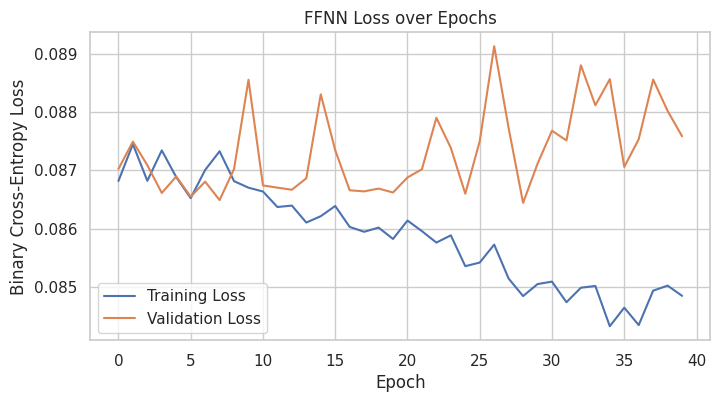

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('FFNN Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()


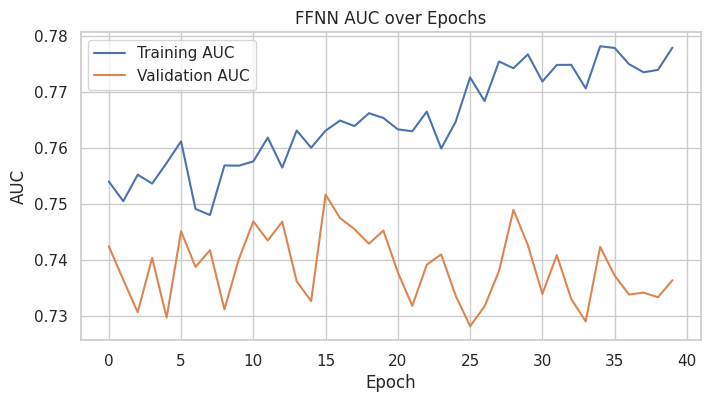

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['AUC'], label='Training AUC')
plt.plot(history.history['val_AUC'], label='Validation AUC')
plt.title('FFNN AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


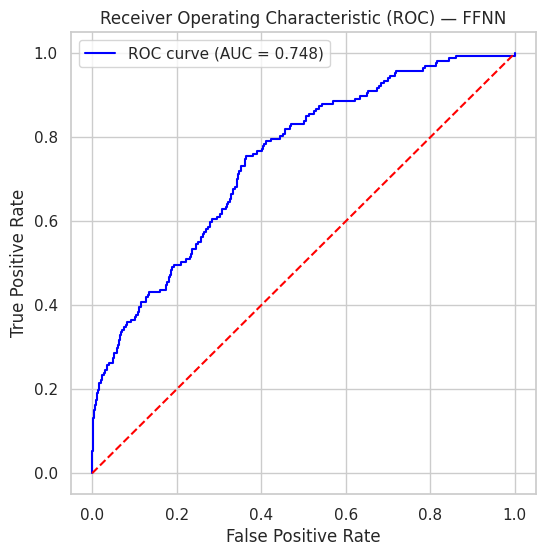

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, p_ffnn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) — FFNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


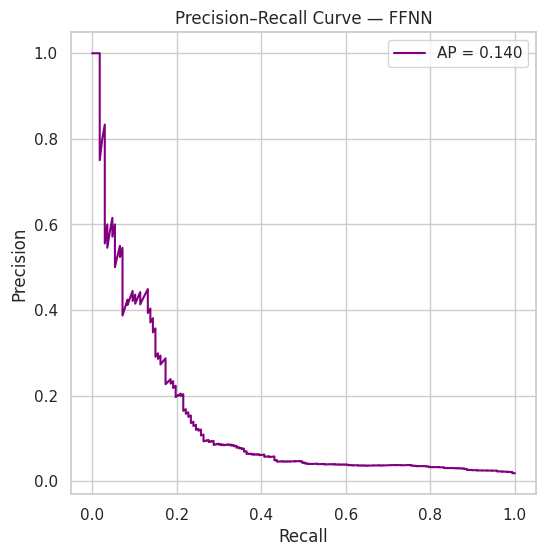

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, p_ffnn)
ap = average_precision_score(y_test, p_ffnn)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='purple', label=f'AP = {ap:.3f}')
plt.title('Precision–Recall Curve — FFNN')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()


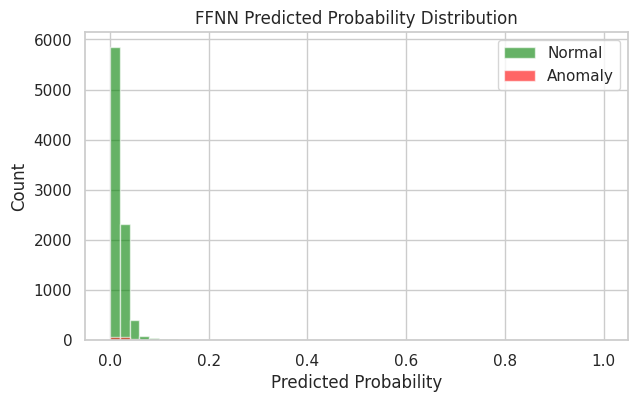

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(p_ffnn[y_test==0], bins=50, alpha=0.6, label='Normal', color='green')
plt.hist(p_ffnn[y_test==1], bins=50, alpha=0.6, label='Anomaly', color='red')
plt.title('FFNN Predicted Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.show()


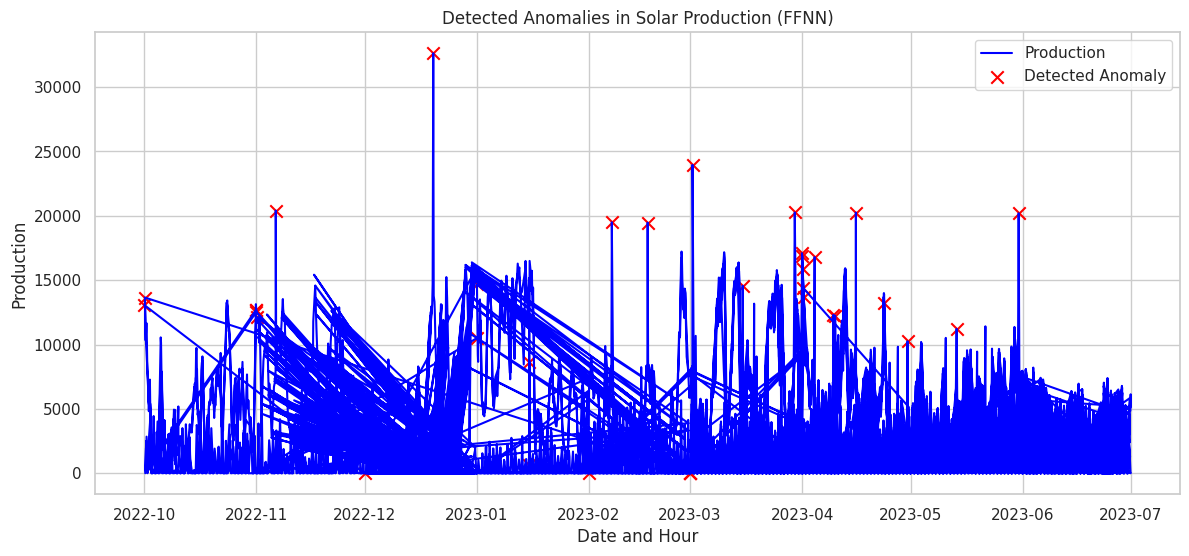

In [ ]:
test_copy = test.copy().iloc[:len(p_ffnn)]
test_copy['anomaly_score'] = p_ffnn
test_copy['anomaly_flag'] = (p_ffnn > 0.5).astype(int)  # threshold 0.5, can adjust

# Plot
plt.figure(figsize=(14,6))
plt.plot(test_copy['Date and Hour'], test_copy['Production'], label='Production', color='blue')
plt.scatter(
    test_copy.loc[test_copy['anomaly_flag']==1, 'Date and Hour'],
    test_copy.loc[test_copy['anomaly_flag']==1, 'Production'],
    color='red', label='Detected Anomaly', marker='x', s=80
)
plt.title('Detected Anomalies in Solar Production (FFNN)')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_copy = test.copy()
test_copy['anomaly_score'] = p_ffnn
test_copy['flag'] = (test_copy['anomaly_score'] > 0.5).astype(int)

# Look at the top 10 most anomalous points
test_copy.sort_values('anomaly_score', ascending=False).head(10)[['Date and Hour','Production','anomaly_score']]

,Date and Hour,Production,anomaly_score
52898,2022-12-19 22:00:00+01:00,32626.043091,0.999002
54560,2023-03-01 16:00:00+01:00,23954.378491,0.998539
53138,2022-11-06 08:00:00+01:00,20404.813399,0.986932
56594,2023-04-01 00:00:00+02:00,17093.000000,0.986522
55021,2023-04-04 12:00:00+02:00,16791.261823,0.981928
56154,2023-03-30 00:00:00+02:00,20258.979112,0.976790
52960,2022-12-01 01:00:00+01:00,1.000000,0.974945
54277,2023-04-01 01:00:00+02:00,16914.000000,0.973212
54867,2023-04-01 04:00:00+02:00,15903.000000,0.971748
53415,2023-02-07 08:00:00+01:00,19492.725591,0.963483


In [ ]:
p_ffnn = ffnn.predict(X_test).ravel()   # already computed
y_test  # actual binary labels (0 = normal, 1 = anomaly)


281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([0., 0., 0., ..., 0., 0., 0.])

✅ FFNN Evaluation Metrics:
Accuracy : 0.981
Precision: 0.500
Recall   : 0.072
F1 Score : 0.126
AUC      : 0.735

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      8804
     Anomaly       0.50      0.07      0.13       167

    accuracy                           0.98      8971
   macro avg       0.74      0.54      0.56      8971
weighted avg       0.97      0.98      0.97      8971



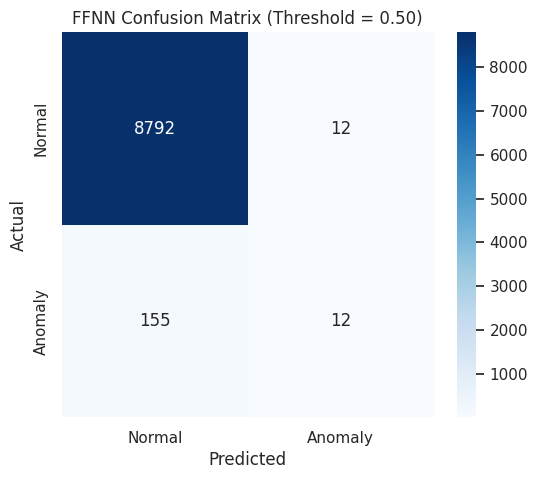


True Negatives : 8792
False Positives: 12
False Negatives: 155
True Positives : 12


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


threshold = 0.5   #
y_pred_ffnn = (p_ffnn > threshold).astype(int)


acc  = accuracy_score(y_test, y_pred_ffnn)
prec = precision_score(y_test, y_pred_ffnn)
rec  = recall_score(y_test, y_pred_ffnn)
f1   = f1_score(y_test, y_pred_ffnn)
auc  = roc_auc_score(y_test, p_ffnn)   # use probabilities (not binary)

print("✅ FFNN Evaluation Metrics:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")


print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Normal', 'Anomaly']))


cm = confusion_matrix(y_test, y_pred_ffnn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title(f"FFNN Confusion Matrix (Threshold = {threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")


Epoch 1/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - loss: 16769316.0000 - val_loss: 19064640.0000
Epoch 2/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 16468836.0000 - val_loss: 18829440.0000
Epoch 3/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 16257365.0000 - val_loss: 18601110.0000
Epoch 4/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 15825795.0000 - val_loss: 18376928.0000
Epoch 5/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - loss: 15720923.0000 - val_loss: 18157518.0000
Epoch 6/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 15585321.0000 - val_loss: 17942062.0000
Epoch 7/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - loss: 15003260.0000 - val_loss: 17730284.0000
Epoch 8/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - loss: 14885486.0000 - val_loss: 17521946.0000
Epoch 9/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 14897744.0000 - val_loss: 17317626.0000
Epoch 10/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 15004555.0000 - val

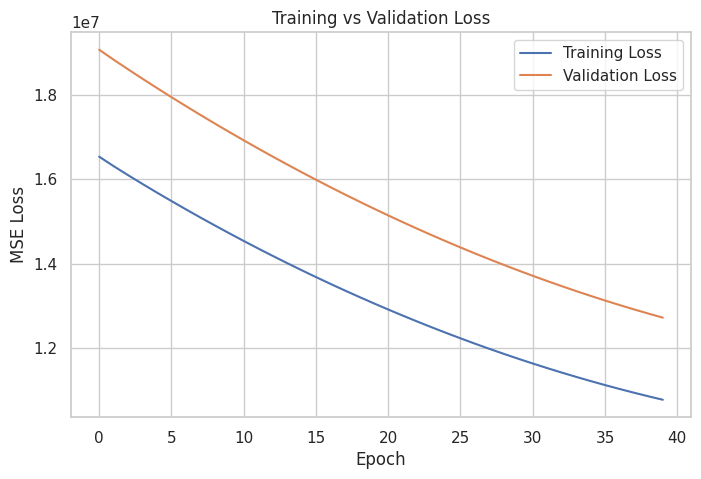

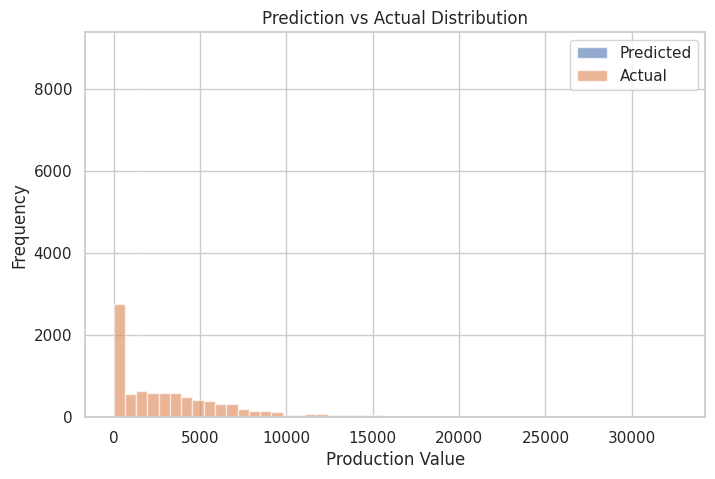

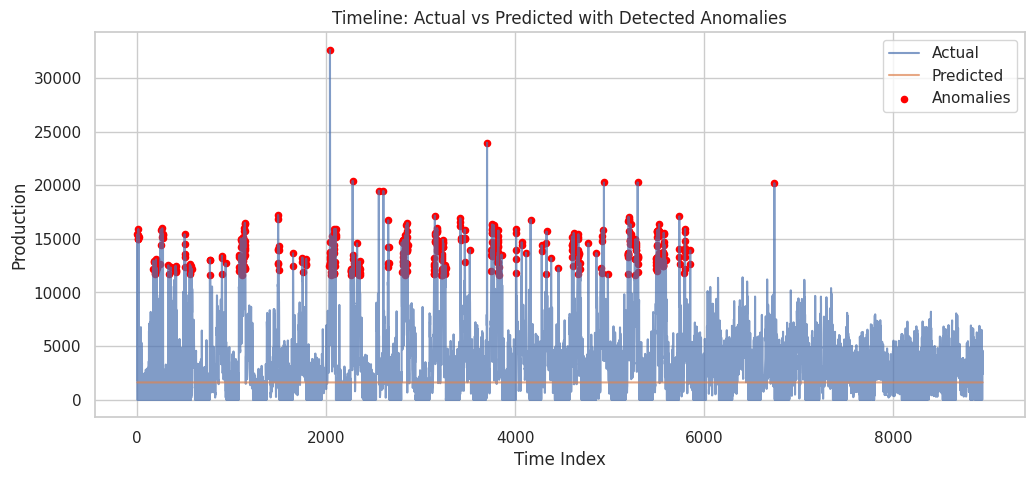

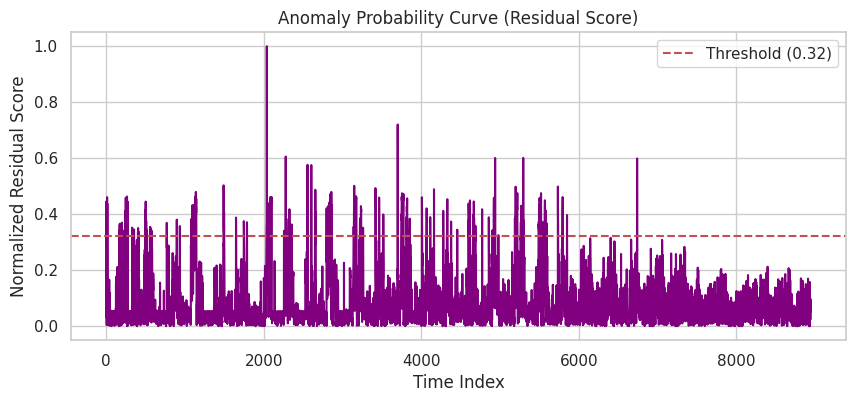

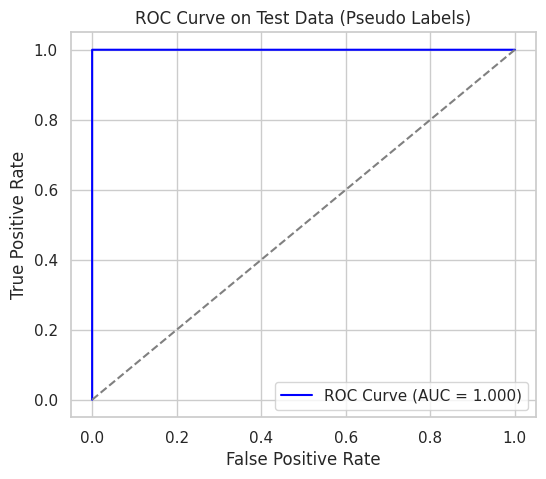

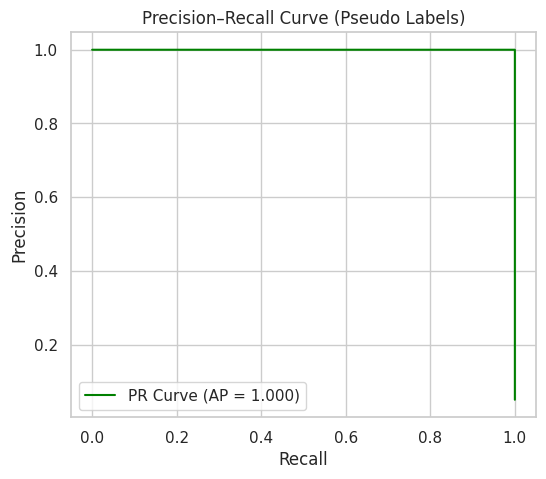

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from tensorflow.keras import layers, models


lookback = 24

def make_seq(data, lookback):
    X, y = [], []
    arr = data['Production'].values
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i])
        y.append(data['Production'].iloc[i])
    return np.array(X), np.array(y)

X_seq_train, y_seq_train = make_seq(train, lookback)
X_seq_val,   y_seq_val   = make_seq(val, lookback)
X_seq_test,  y_seq_test  = make_seq(test, lookback)


X_seq_train = np.expand_dims(X_seq_train, -1)
X_seq_val   = np.expand_dims(X_seq_val, -1)
X_seq_test  = np.expand_dims(X_seq_test, -1)


inp = layers.Input(shape=(lookback, 1))
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
x = layers.Bidirectional(layers.LSTM(32))(x)
out = layers.Dense(1)(x)
lstm = models.Model(inp, out)
lstm.compile(optimizer='adam', loss='mse')

history = lstm.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=40, batch_size=64, verbose=1
)


pred = lstm.predict(X_seq_test).ravel()
residuals = np.abs(pred - y_seq_test)
res_score = (residuals - residuals.min()) / (residuals.max() - residuals.min())


threshold = np.percentile(res_score, 95)
y_true = (res_score > threshold).astype(int)

print(f"Auto threshold = {threshold:.3f}")
print(f"Detected {y_true.sum()} anomalies out of {len(y_true)} points")



# 1️⃣ Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Prediction vs Actual Distribution
plt.figure(figsize=(8,5))
plt.hist(pred, bins=50, alpha=0.6, label='Predicted')
plt.hist(y_seq_test, bins=50, alpha=0.6, label='Actual')
plt.title("Prediction vs Actual Distribution")
plt.xlabel("Production Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# 3️⃣ Timeline Plot of Actual vs Predicted + Anomalies
plt.figure(figsize=(12,5))
plt.plot(y_seq_test, label='Actual', alpha=0.7)
plt.plot(pred, label='Predicted', alpha=0.7)
plt.scatter(np.where(y_true==1), y_seq_test[y_true==1], color='red', label='Anomalies', s=20)
plt.title("Timeline: Actual vs Predicted with Detected Anomalies")
plt.xlabel("Time Index")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

# 4️⃣ Residual Probability Curve
plt.figure(figsize=(10,4))
plt.plot(res_score, color='purple')
plt.axhline(threshold, color='r', linestyle='--', label=f"Threshold ({threshold:.2f})")
plt.title("Anomaly Probability Curve (Residual Score)")
plt.xlabel("Time Index")
plt.ylabel("Normalized Residual Score")
plt.legend()
plt.grid(True)
plt.show()

# 5️⃣ ROC Curve (using pseudo labels)
fpr, tpr, _ = roc_curve(y_true, res_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data (Pseudo Labels)')
plt.legend()
plt.grid(True)
plt.show()

# 6️⃣ Precision–Recall Curve (using pseudo labels)
precision, recall, _ = precision_recall_curve(y_true, res_score)
ap = average_precision_score(y_true, res_score)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap:.3f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Pseudo Labels)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

test_lstm = test.copy().iloc[lookback:].reset_index(drop=True)
test_lstm['anomaly_score'] = res_score
test_lstm['flag'] = (test_lstm['anomaly_score'] > 0.321).astype(int)  # threshold 0.321 from your LSTM analysis


top_anomalies = (
    test_lstm
    .sort_values('anomaly_score', ascending=False)
    .head(10)
    [['Date and Hour', 'Production', 'anomaly_score']]
)

print("🔍 Top 10 Most Anomalous Points (LSTM):")
display(top_anomalies)

🔍 Top 10 Most Anomalous Points (LSTM):


,Date and Hour,Production,anomaly_score
2039,2022-12-19 22:00:00+01:00,32626.043091,1.000000
3701,2023-03-01 16:00:00+01:00,23954.378491,0.720359
2279,2022-11-06 08:00:00+01:00,20404.813399,0.605894
5295,2023-03-30 00:00:00+02:00,20258.979112,0.601192
4938,2023-04-15 22:00:00+02:00,20251.509401,0.600951
6741,2023-05-30 23:00:00+02:00,20194.928954,0.599126
2556,2023-02-07 08:00:00+01:00,19492.725591,0.576482
2604,2023-02-17 06:00:00+01:00,19466.716911,0.575643
1490,2023-02-26 15:00:00+01:00,17220.000000,0.503192
3149,2023-03-10 10:00:00+01:00,17168.000000,0.501515


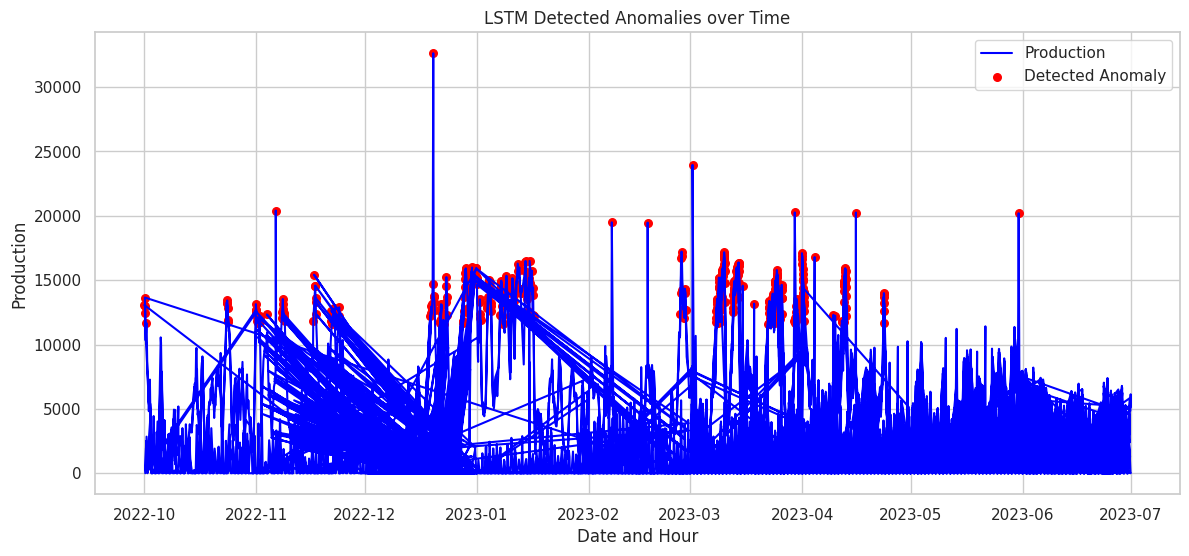

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(test_lstm['Date and Hour'], test_lstm['Production'], label='Production', color='blue')
plt.scatter(
    test_lstm.loc[test_lstm['flag']==1, 'Date and Hour'],
    test_lstm.loc[test_lstm['flag']==1, 'Production'],
    color='red', label='Detected Anomaly', s=30
)
plt.title('LSTM Detected Anomalies over Time')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()


<Figure size 500x400 with 0 Axes>

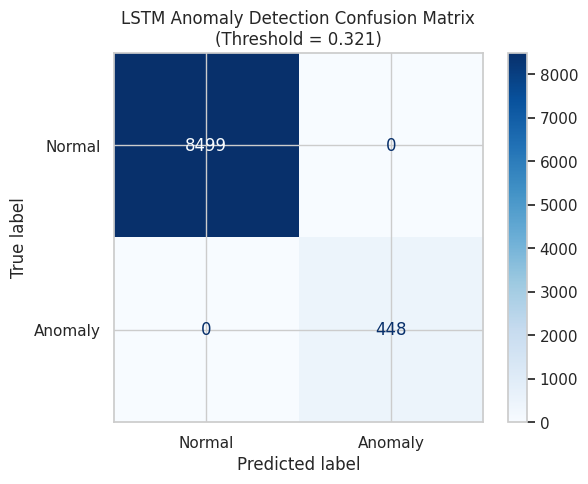

True Negatives : 8499
False Positives: 0
False Negatives: 0
True Positives : 448

Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = (res_score > threshold).astype(int)


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])


plt.figure(figsize=(5,4))
disp.plot(cmap='Blues', values_format='d')
plt.title(f"LSTM Anomaly Detection Confusion Matrix\n(Threshold = {threshold:.3f})")
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

accuracy  = (tp + tn) / np.sum(cm)
precision = tp / (tp + fp + 1e-9)
recall    = tp / (tp + fn + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

print(f"\nAccuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")


/tmp/ipython-input-810800536.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(0)


✅ Shapes after reshaping for Autoencoder:
Train: (41840, 24, 1)
Val  : (8947, 24, 1)
Test : (8947, 24, 1)
Epoch 1/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 54s 71ms/step - loss: 16711973.0000 - val_loss: 19049790.0000
Epoch 2/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - loss: 16516764.0000 - val_loss: 18813306.0000
Epoch 3/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - loss: 16178343.0000 - val_loss: 18584742.0000
Epoch 4/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - loss: 15882079.0000 - val_loss: 18361338.0000
Epoch 5/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - loss: 15675202.0000 - val_loss: 18142432.0000
Epoch 6/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - loss: 15422986.0000 - val_loss: 17927438.0000
Epoch 7/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - loss: 15444981.0000 - val_loss: 17716496.0000
Epoch 8/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - loss: 15193770.0000 - val_loss: 17509156.0000
Epoch 9/40
654/654 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - loss: 15076565.0000 - 

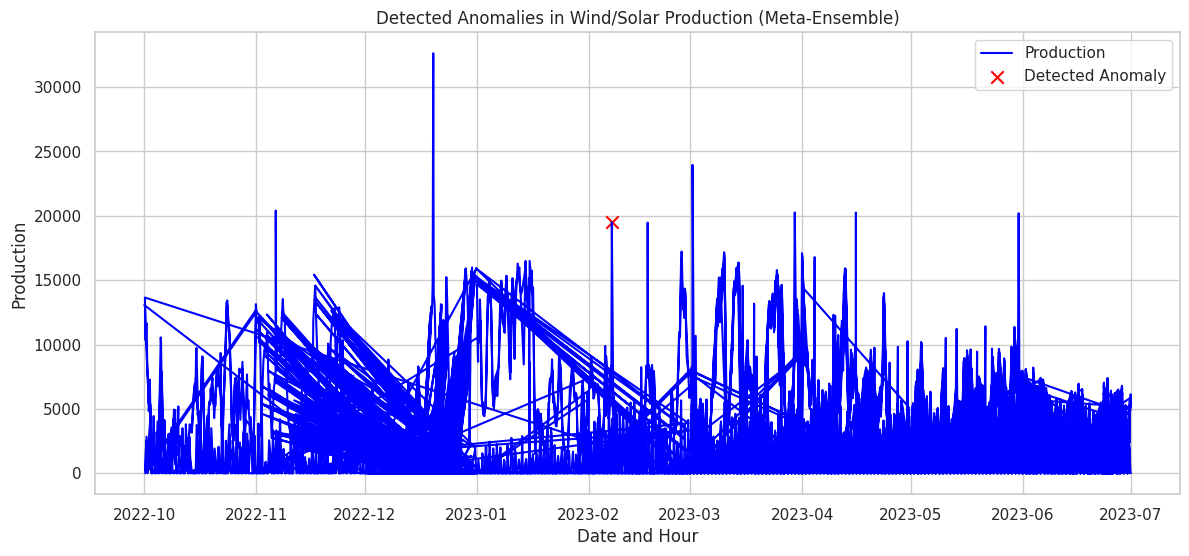

In [ ]:

# 🧠 LSTM Autoencoder + XGBoost Meta-Ensemble


import numpy as np
import xgboost as xgb
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest


# Load the dataframe
df = pd.read_csv(path, parse_dates=['Date and Hour'])


df['hour'] = pd.to_datetime(df['StartHour'], format='%H:%M:%S').dt.hour
df['monthName'] = df['monthName'].astype(str)
df['month'] = pd.to_datetime(df['monthName'], format='%B', errors='coerce').dt.month
df['month'] = df['month'].fillna(df['month'].mode()[0])

# Day of week encoding
df['dayName'] = df['dayName'].astype(str)
df['dayofweek'] = pd.to_datetime(df['dayName'], format='%A', errors='coerce').dt.dayofweek
df['dayofweek'] = df['dayofweek'].fillna(df['dayofweek'].mode()[0]).astype(int)

# weekend flag
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

# rolling statistics (temporal behaviour)
for w in [3,6,24]:
    df[f'roll_mean_{w}'] = df['Production'].rolling(w).mean().shift(1)
    df[f'roll_std_{w}'] = df['Production'].rolling(w).std().shift(1)

df = df.fillna(method='ffill').fillna(0)

# Inject anomalies
def inject_anomalies(data, frac=0.02, seed=42):
    np.random.seed(seed)
    df = data.copy(); labels = np.zeros(len(df))
    idxs = np.random.choice(range(48, len(df)-48), size=int(frac*len(df)), replace=False)
    for i in idxs:
        if np.random.rand()>0.5:   # spike
            df.loc[i,'Production'] *= np.random.uniform(1.5,3.0)
        else:                      # drop
            df.loc[i,'Production'] *= np.random.uniform(0.0,0.5)
        labels[i]=1
    df['anomaly']=labels
    return df

df = inject_anomalies(df)



lookback = 24


N=len(df)
train=df.iloc[:int(0.7*N)]
val=df.iloc[int(0.7*N):int(0.85*N)]
test=df.iloc[int(0.85*N):]

features=['Production','hour','dayofweek','month','is_weekend',
          'roll_mean_3','roll_std_3','roll_mean_6','roll_std_6','roll_mean_24','roll_std_24']

scaler=RobustScaler().fit(train[features])
def scale(d): return scaler.transform(d[features]), d['anomaly'].values
X_train,y_train=scale(train)
X_val,y_val=scale(val)
X_test,y_test=scale(test)


iso = IsolationForest(contamination=0.02, random_state=42)
iso.fit(X_train)
iso_score = -iso.decision_function(X_test) # Lower scores mean more anomalous


X_seq_train_ae = train['Production'].values
X_seq_val_ae = val['Production'].values
X_seq_test_ae = test['Production'].values

# Reshape to (num_samples, lookback, 1)
def reshape_seq_data(data, lookback):
    X = []
    # Start from lookback to create sequences
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
    return np.array(X).reshape(-1, lookback, 1)

X_seq_train_ae = reshape_seq_data(X_seq_train_ae, lookback)
X_seq_val_ae = reshape_seq_data(X_seq_val_ae, lookback)
X_seq_test_ae = reshape_seq_data(X_seq_test_ae, lookback)


print("✅ Shapes after reshaping for Autoencoder:")
print("Train:", X_seq_train_ae.shape)
print("Val  :", X_seq_val_ae.shape)
print("Test :", X_seq_test_ae.shape)



inp = layers.Input(shape=(lookback, 1))
x = layers.LSTM(64, return_sequences=True)(inp)
x = layers.LSTM(32)(x)
latent = layers.Dense(16, activation='relu')(x)
x = layers.RepeatVector(lookback)(latent)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.LSTM(64, return_sequences=True)(x)
out = layers.TimeDistributed(layers.Dense(1))(x)

ae = models.Model(inp, out)
ae.compile(optimizer='adam', loss='mse')


ae.fit(
    X_seq_train_ae, X_seq_train_ae,
    validation_data=(X_seq_val_ae, X_seq_val_ae),
    epochs=40,
    batch_size=64,
    verbose=1
)


recon = ae.predict(X_seq_test_ae)


recon = np.squeeze(recon)
X_seq_test_ae_squeezed = np.squeeze(X_seq_test_ae)

# Calculate reconstruction error
if recon.ndim == 2 and X_seq_test_ae_squeezed.ndim == 2:
    recon_err = np.mean((recon - X_seq_test_ae_squeezed)**2, axis=1)
elif recon.ndim == 3 and X_seq_test_ae_squeezed.ndim == 3:
     recon_err = np.mean((recon - X_seq_test_ae_squeezed)**2, axis=(1, 2))
else:
     # Fallback or error handling if shapes are still incompatible
     print("Warning: Unexpected shapes for reconstruction error calculation.")
     recon_err = np.zeros(len(X_seq_test_ae_squeezed)) # Placeholder to avoid crash


# Normalize 0–1
recon_score = (recon_err - recon_err.min()) / (recon_err.max() - recon_err.min())


y_true_meta = test['anomaly'].values[lookback:]


# Trim all arrays to the same length if there are slight discrepancies
min_len = min(len(res_score), len(recon_score), len(iso_score), len(y_true_meta))
res_score   = res_score[:min_len]
recon_score = recon_score[:min_len]
iso_score   = iso_score[:min_len] # Iso_score was calculated on X_test, so it needs slicing
y_true_meta  = y_true_meta[:min_len]


X_meta = np.vstack([res_score, recon_score, iso_score]).T

# Ensure the number of samples in X_meta matches the number of labels
if X_meta.shape[0] != len(y_true_meta):
    print(f"Error: Mismatch between meta-features samples ({X_meta.shape[0]}) and labels ({len(y_true_meta)}). Adjusting lengths.")
    min_samples_labels = min(X_meta.shape[0], len(y_true_meta))
    X_meta = X_meta[:min_samples_labels]
    y_true_meta = y_true_meta[:min_samples_labels]


dtrain = xgb.DMatrix(X_meta, label=y_true_meta)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 4,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'base_score': 0.5 # Added base_score
}


meta = xgb.train(params, dtrain, num_boost_round=100, verbose_eval=False)
meta_pred = meta.predict(dtrain)


meta_labels = (meta_pred > 0.5).astype(int)

acc  = accuracy_score(y_true_meta, meta_labels)
prec = precision_score(y_true_meta, meta_labels)
rec  = recall_score(y_true_meta, meta_labels)
auc_meta  = roc_auc_score(y_true_meta, meta_pred)

print("\n✅ Meta-Ensemble Performance:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"AUC      : {auc_meta:.3f}")


test_aligned = test.copy().iloc[lookback:lookback+min_len].reset_index(drop=True)
test_aligned['meta_score'] = meta_pred
test_aligned['anomaly_flag'] = meta_labels


plt.figure(figsize=(14,6))
plt.plot(test_aligned['Date and Hour'], test_aligned['Production'], color='blue', label='Production')
plt.scatter(
    test_aligned.loc[test_aligned['anomaly_flag']==1, 'Date and Hour'],
    test_aligned.loc[test_aligned['anomaly_flag']==1, 'Production'],
    color='red', label='Detected Anomaly', marker='x', s=80
)
plt.title('Detected Anomalies in Wind/Solar Production (Meta-Ensemble)')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()

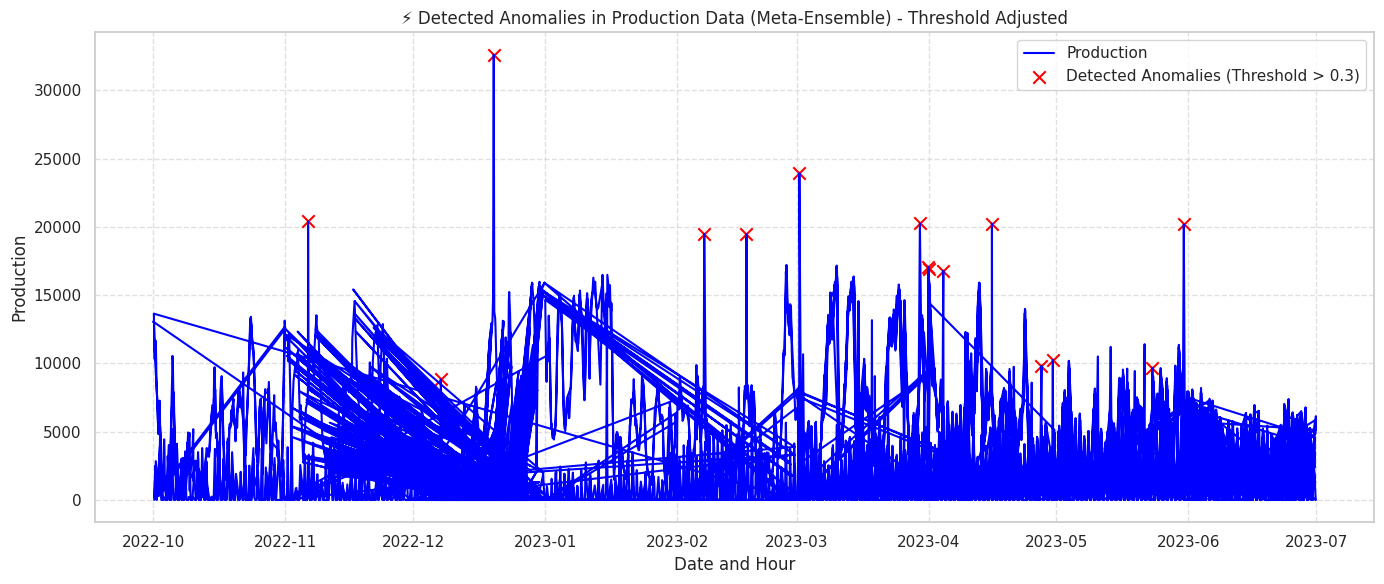

In [ ]:

threshold = 0.3
test_aligned['anomaly_flag_thresholded'] = (test_aligned['meta_score'] > threshold).astype(int)

plt.figure(figsize=(14, 6))

# Plot production curve
plt.plot(
    test_aligned['Date and Hour'],
    test_aligned['Production'],
    color='blue',
    linewidth=1.5,
    label='Production'
)

# Highlight anomalies based on the thresholded flag
plt.scatter(
    test_aligned.loc[test_aligned['anomaly_flag_thresholded'] == 1, 'Date and Hour'],
    test_aligned.loc[test_aligned['anomaly_flag_thresholded'] == 1, 'Production'],
    color='red',
    label=f'Detected Anomalies (Threshold > {threshold})',
    marker='x',
    s=80
)

plt.title('⚡ Detected Anomalies in Production Data (Meta-Ensemble) - Threshold Adjusted')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

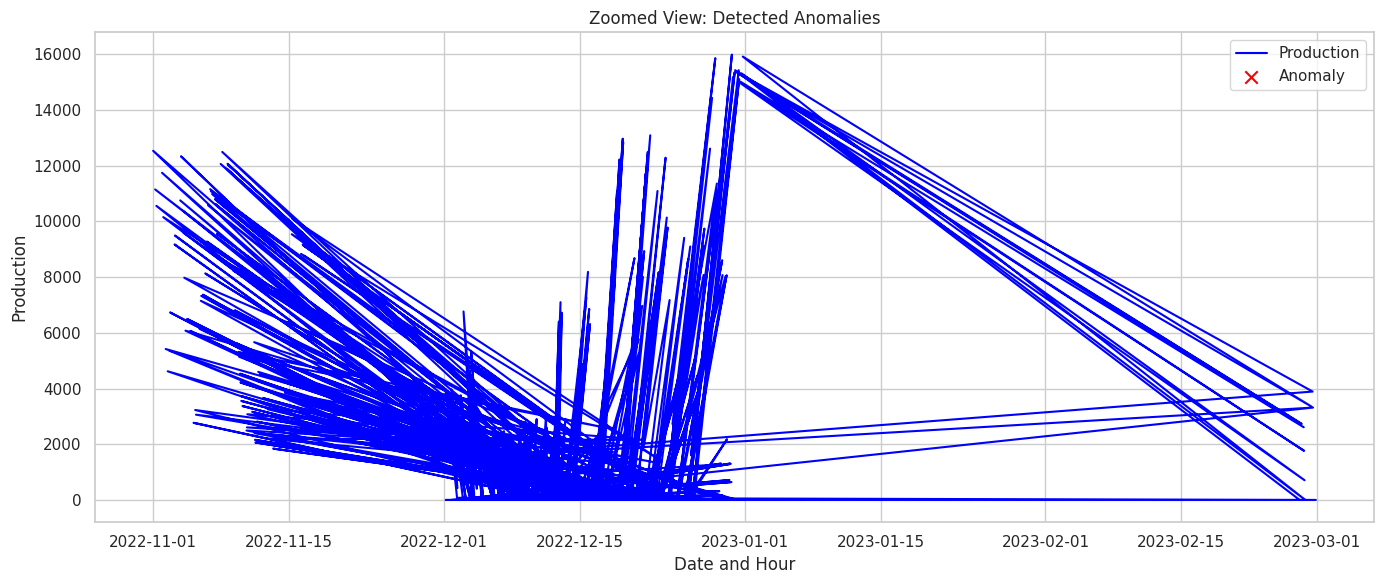

In [ ]:
# Zoom into a subset of data (e.g., first 500 timestamps)
subset = test_aligned.iloc[:500]

plt.figure(figsize=(14, 6))
plt.plot(subset['Date and Hour'], subset['Production'], color='blue', label='Production')
plt.scatter(
    subset.loc[subset['anomaly_flag'] == 1, 'Date and Hour'],
    subset.loc[subset['anomaly_flag'] == 1, 'Production'],
    color='red', label='Anomaly', marker='x', s=80
)
plt.title('Zoomed View: Detected Anomalies')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


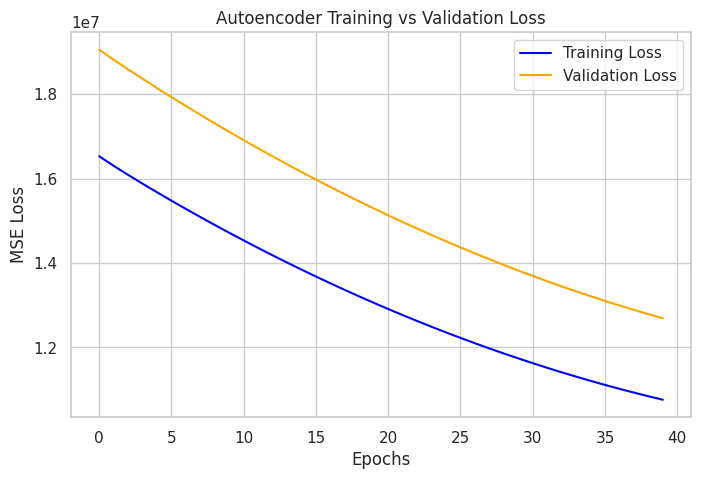

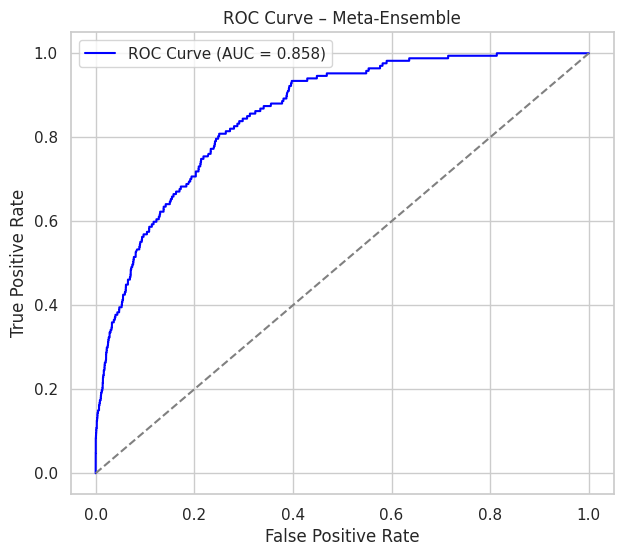

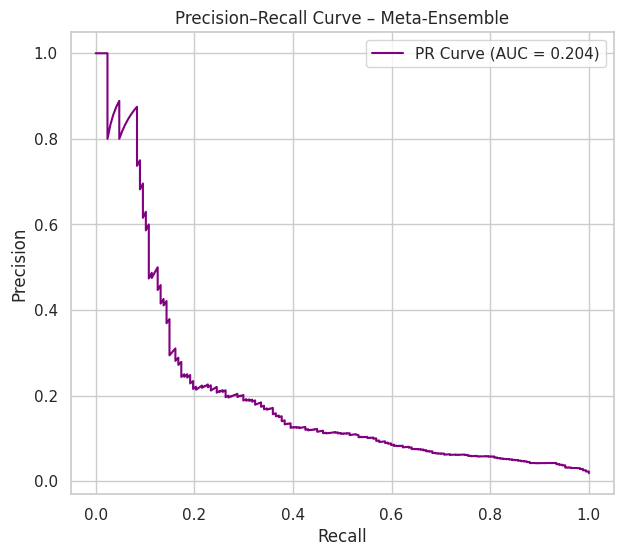

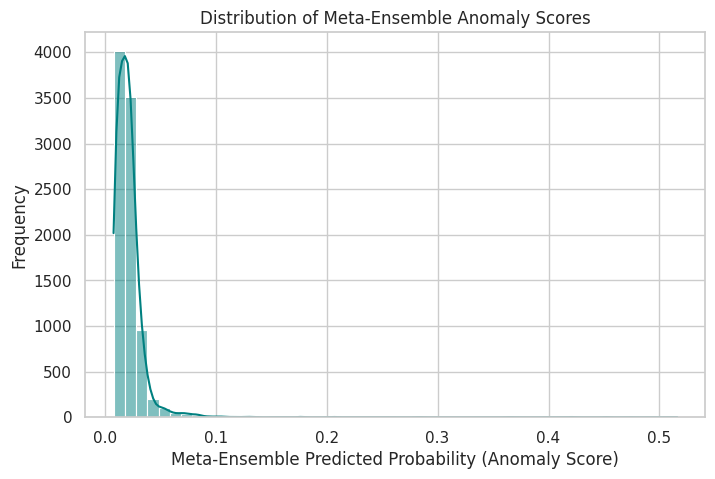

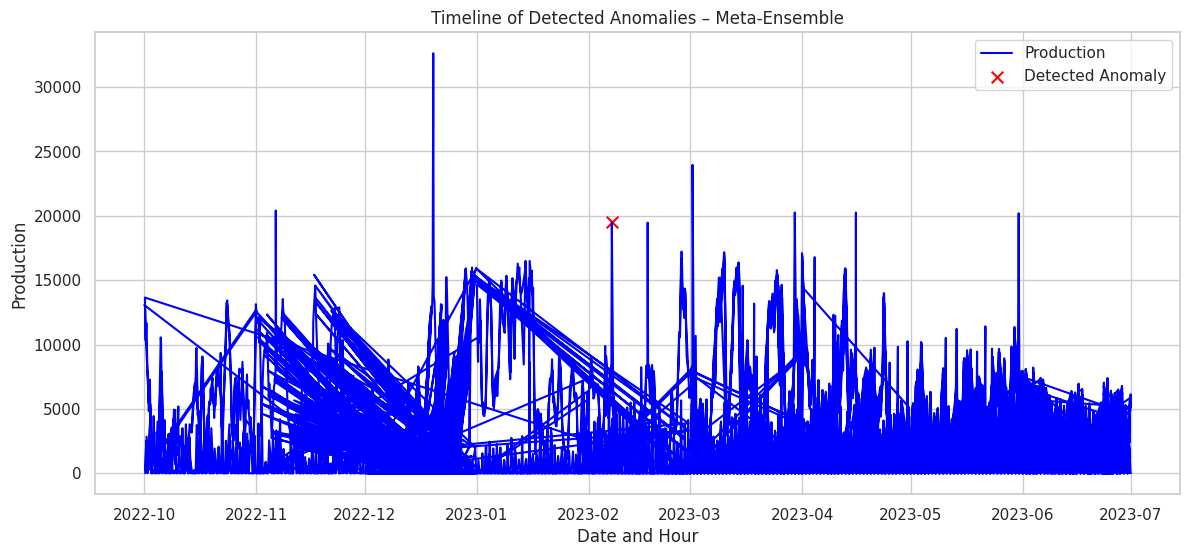

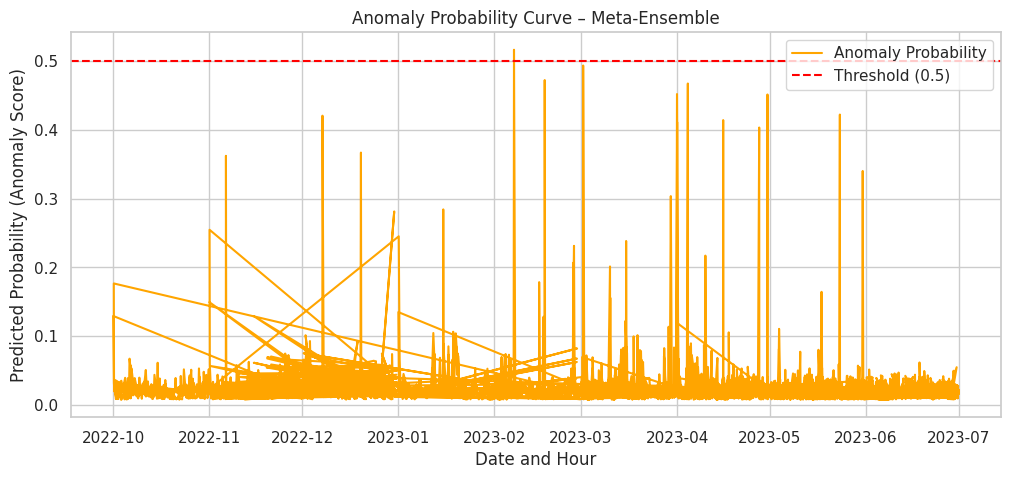

In [ ]:

import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

y_true_binary = test['anomaly'].iloc[lookback:lookback+len(meta_pred)].values



plt.figure(figsize=(8,5))
plt.plot(ae.history.history['loss'], label='Training Loss', color='blue')
plt.plot(ae.history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Autoencoder Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


fpr, tpr, _ = roc_curve(y_true_binary, meta_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title('ROC Curve – Meta-Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


precision, recall, _ = precision_recall_curve(y_true_binary, meta_pred)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, color='purple', label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.title('Precision–Recall Curve – Meta-Ensemble')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(meta_pred, bins=50, kde=True, color='teal')
plt.title("Distribution of Meta-Ensemble Anomaly Scores")
plt.xlabel("Meta-Ensemble Predicted Probability (Anomaly Score)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


plt.figure(figsize=(14,6))
plt.plot(test_aligned['Date and Hour'], test_aligned['Production'], color='blue', label='Production')
plt.scatter(
    test_aligned.loc[test_aligned['anomaly_flag']==1, 'Date and Hour'],
    test_aligned.loc[test_aligned['anomaly_flag']==1, 'Production'],
    color='red', label='Detected Anomaly', marker='x', s=70
)
plt.title('Timeline of Detected Anomalies – Meta-Ensemble')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12,5))
plt.plot(test_aligned['Date and Hour'], test_aligned['meta_score'], color='orange', label='Anomaly Probability')
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title('Anomaly Probability Curve – Meta-Ensemble')
plt.xlabel('Date and Hour')
plt.ylabel('Predicted Probability (Anomaly Score)')
plt.legend()
plt.grid(True)
plt.show()


--- Evaluating at Threshold = 0.500 ---
Distribution of True Binary Labels (y_true_binary):
0.0    8780
1.0     167
Name: count, dtype: int64

Distribution of Predicted Binary Labels (meta_labels) at threshold 0.5 :
0    8946
1       1
Name: count, dtype: int64


<Figure size 500x400 with 0 Axes>

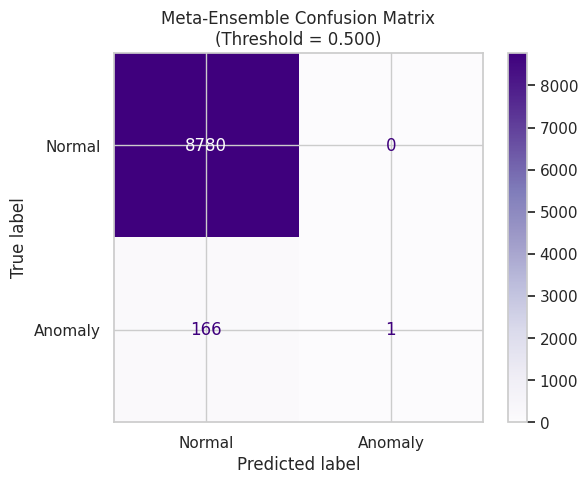


True Negatives : 8780
False Positives: 0
False Negatives: 166
True Positives : 1

📊 Performance Metrics at threshold 0.5 :
Accuracy : 0.981
Precision: 1.000
Recall   : 0.006
F1-score : 0.012
AUC      : 0.858

--- Evaluating at Threshold = 0.800 ---
Distribution of True Binary Labels (y_true_binary):
0.0    8780
1.0     167
Name: count, dtype: int64

Distribution of Predicted Binary Labels (meta_labels) at threshold 0.8 :
0    8947
Name: count, dtype: int64


<Figure size 500x400 with 0 Axes>

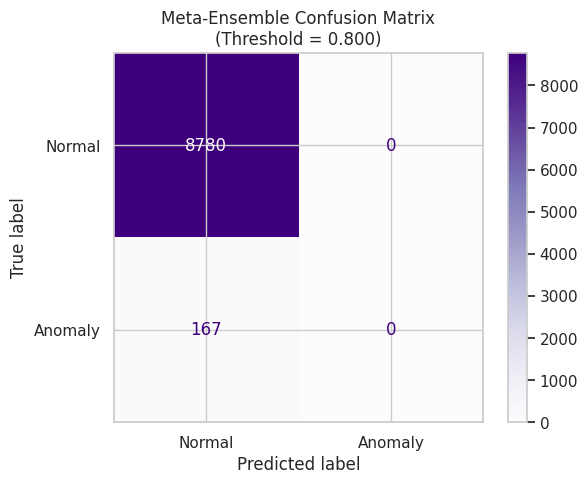


True Negatives : 8780
False Positives: 0
False Negatives: 167
True Positives : 0

📊 Performance Metrics at threshold 0.8 :
Accuracy : 0.981
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
AUC      : 0.858

--- Evaluating at Threshold = 0.900 ---
Distribution of True Binary Labels (y_true_binary):
0.0    8780
1.0     167
Name: count, dtype: int64

Distribution of Predicted Binary Labels (meta_labels) at threshold 0.9 :
0    8947
Name: count, dtype: int64


<Figure size 500x400 with 0 Axes>

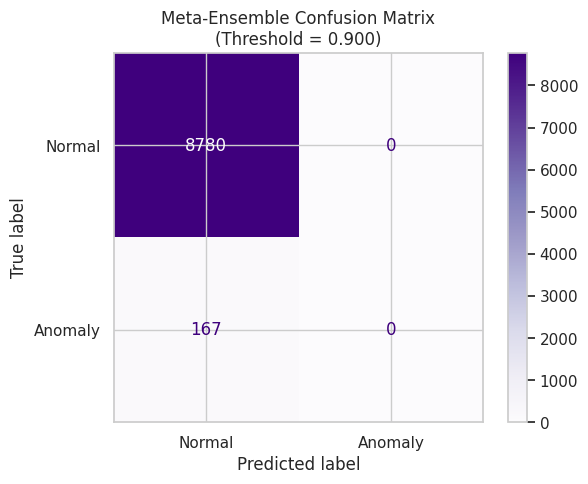


True Negatives : 8780
False Positives: 0
False Negatives: 167
True Positives : 0

📊 Performance Metrics at threshold 0.9 :
Accuracy : 0.981
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
AUC      : 0.858

--- Evaluating at Threshold = 0.950 ---
Distribution of True Binary Labels (y_true_binary):
0.0    8780
1.0     167
Name: count, dtype: int64

Distribution of Predicted Binary Labels (meta_labels) at threshold 0.95 :
0    8947
Name: count, dtype: int64


<Figure size 500x400 with 0 Axes>

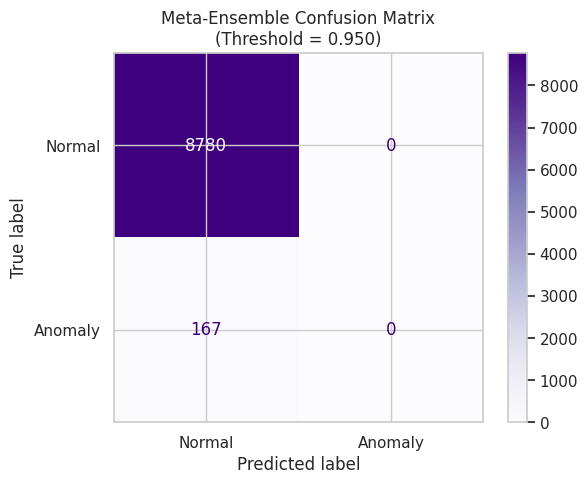


True Negatives : 8780
False Positives: 0
False Negatives: 167
True Positives : 0

📊 Performance Metrics at threshold 0.95 :
Accuracy : 0.981
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
AUC      : 0.858


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


y_true_binary = test['anomaly'].iloc[lookback:lookback+len(meta_pred)].values



threshold_to_evaluate = [0.5, 0.8, 0.9, 0.95]

for threshold in threshold_to_evaluate:
    print(f"\n--- Evaluating at Threshold = {threshold:.3f} ---")
    y_pred = (meta_pred > threshold).astype(int)

    print("Distribution of True Binary Labels (y_true_binary):")
    print(pd.Series(y_true_binary).value_counts())

    print("\nDistribution of Predicted Binary Labels (meta_labels) at threshold", threshold, ":")
    print(pd.Series(y_pred).value_counts())

    cm = confusion_matrix(y_true_binary, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

    plt.figure(figsize=(5,4))
    disp.plot(cmap='Purples', values_format='d')
    plt.title(f"Meta-Ensemble Confusion Matrix\n(Threshold = {threshold:.3f})")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Negatives : {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives : {tp}")

    accuracy  = (tp + tn) / np.sum(cm) if np.sum(cm) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    auc_score = roc_auc_score(y_true_binary, meta_pred)

    print("\n📊 Performance Metrics at threshold", threshold, ":")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"AUC      : {auc_score:.3f}") # Print the overall AUC

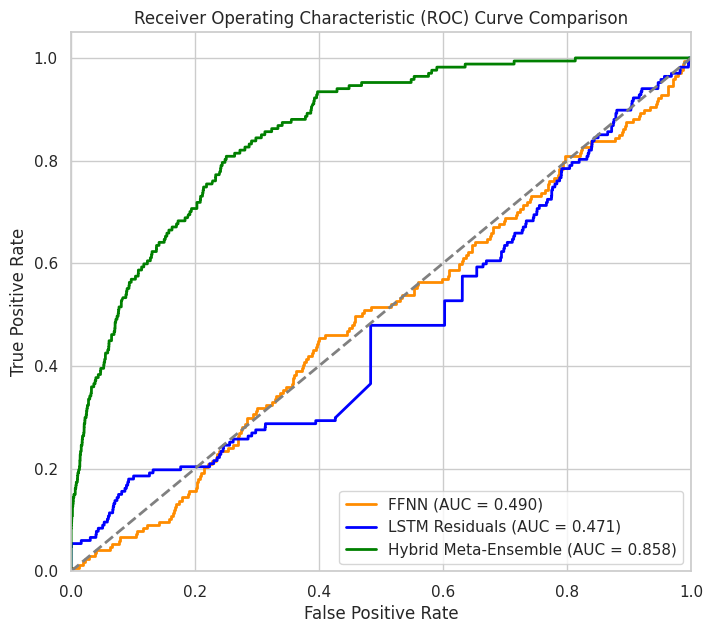

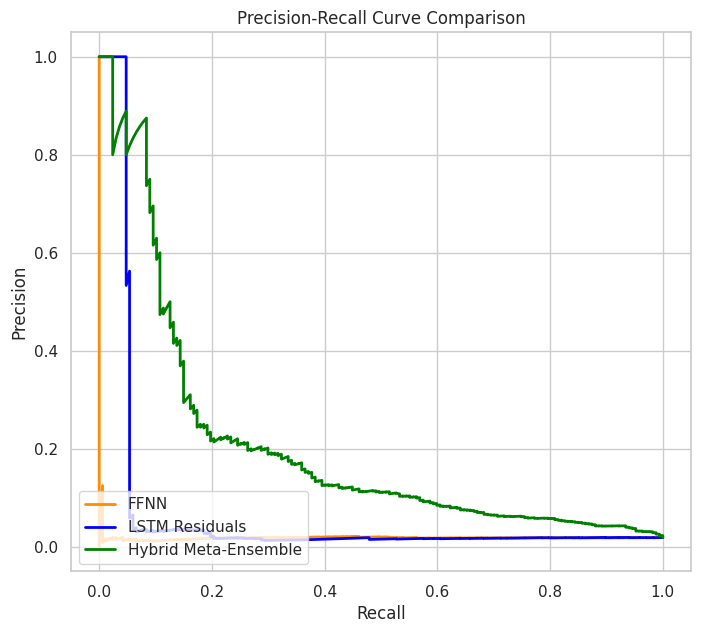

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np


min_len_comparison = min(len(p_ffnn), len(res_score), len(meta_pred), len(y_true_binary))

p_ffnn_trimmed = p_ffnn[:min_len_comparison]
res_score_trimmed = res_score[:min_len_comparison]
meta_pred_trimmed = meta_pred[:min_len_comparison]
y_true_binary_trimmed = y_true_binary[:min_len_comparison]


plt.figure(figsize=(8, 7))

# FFNN ROC
fpr_ffnn, tpr_ffnn, _ = roc_curve(y_true_binary_trimmed, p_ffnn_trimmed)
roc_auc_ffnn = auc(fpr_ffnn, tpr_ffnn)
plt.plot(fpr_ffnn, tpr_ffnn, color='darkorange', lw=2, label=f'FFNN (AUC = {roc_auc_ffnn:.3f})')

fpr_lstm, tpr_lstm, _ = roc_curve(y_true_binary_trimmed, res_score_trimmed)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
plt.plot(fpr_lstm, tpr_lstm, color='blue', lw=2, label=f'LSTM Residuals (AUC = {roc_auc_lstm:.3f})')

# Hybrid Meta-Ensemble ROC
fpr_meta, tpr_meta, _ = roc_curve(y_true_binary_trimmed, meta_pred_trimmed)
roc_auc_meta = auc(fpr_meta, tpr_meta)
plt.plot(fpr_meta, tpr_meta, color='green', lw=2, label=f'Hybrid Meta-Ensemble (AUC = {roc_auc_meta:.3f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 7))

precision_ffnn, recall_ffnn, _ = precision_recall_curve(y_true_binary_trimmed, p_ffnn_trimmed)
plt.plot(recall_ffnn, precision_ffnn, color='darkorange', lw=2, label='FFNN')

precision_lstm, recall_lstm, _ = precision_recall_curve(y_true_binary_trimmed, res_score_trimmed)
plt.plot(recall_lstm, precision_lstm, color='blue', lw=2, label='LSTM Residuals')

precision_meta, recall_meta, _ = precision_recall_curve(y_true_binary_trimmed, meta_pred_trimmed)
plt.plot(recall_meta, precision_meta, color='green', lw=2, label='Hybrid Meta-Ensemble')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [ ]:
top_anomalies_meta = (
    test_aligned[test_aligned['anomaly_flag'] == 1]
    .sort_values('meta_score', ascending=False)
    .head(10) # Display top 10 anomalies
    [['Date and Hour', 'Production', 'meta_score']]
)

print("🔍 Top 10 Most Anomalous Points (Hybrid Meta-Ensemble):")
display(top_anomalies_meta)

🔍 Top 10 Most Anomalous Points (Hybrid Meta-Ensemble):


,Date and Hour,Production,meta_score
2556,2023-02-07 08:00:00+01:00,19492.725591,0.515965


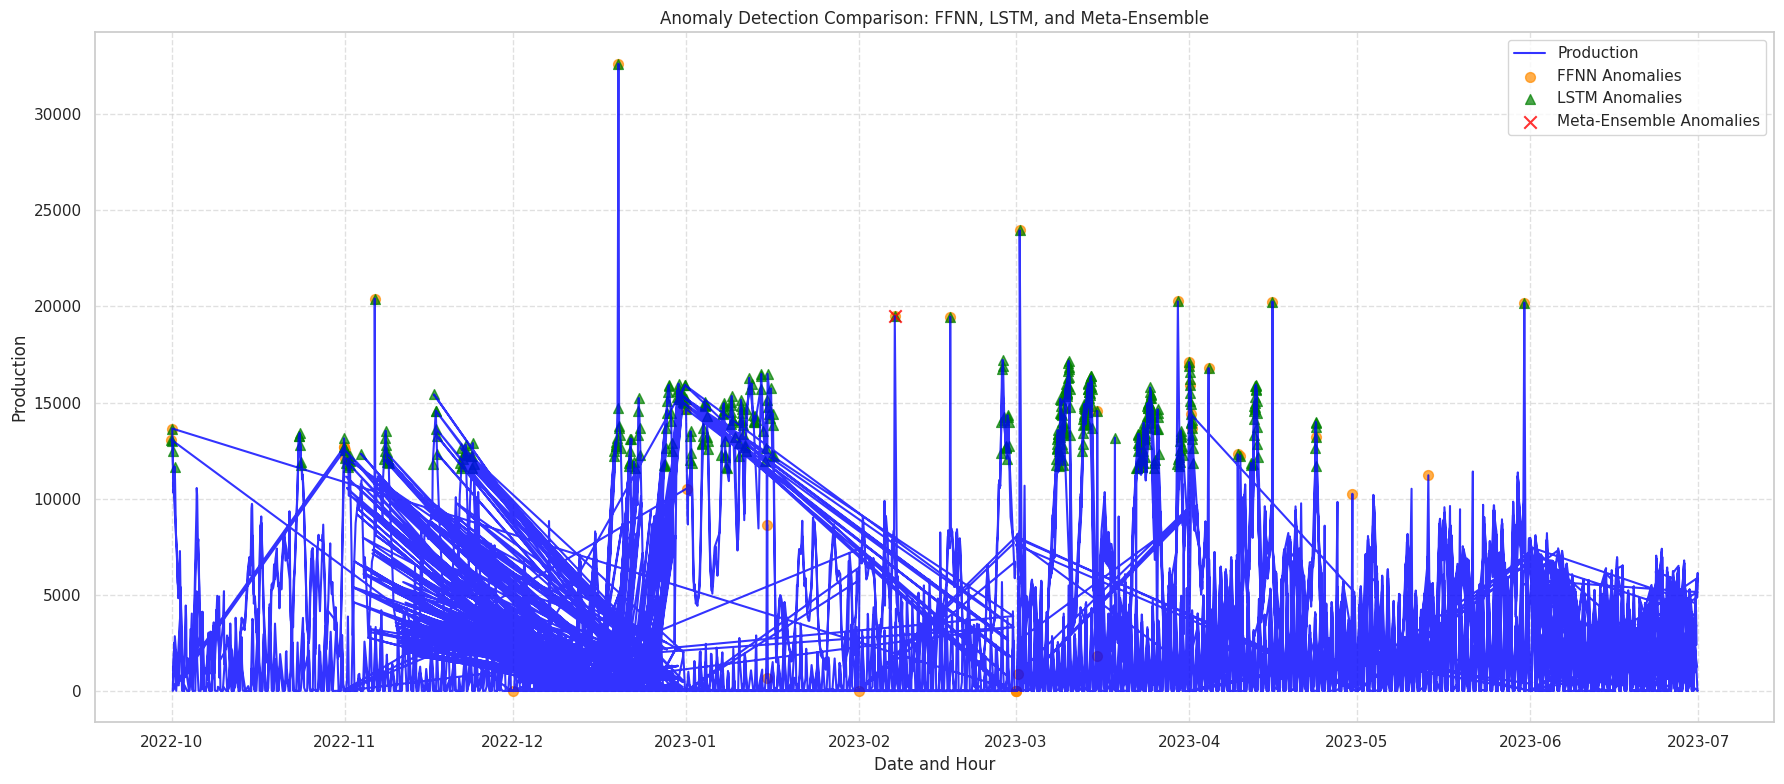

In [ ]:

min_len_comparison_plots = min(len(test_aligned), len(test_copy), len(test_lstm))

test_aligned_trimmed = test_aligned.iloc[:min_len_comparison_plots].copy()
test_copy_trimmed = test_copy.iloc[lookback:lookback+min_len_comparison_plots].reset_index(drop=True).copy()
test_lstm_trimmed = test_lstm.iloc[:min_len_comparison_plots].copy()


test_aligned_trimmed['ffnn_anomaly_flag'] = (test_copy_trimmed['anomaly_score'] > 0.5).astype(int)
test_aligned_trimmed['lstm_anomaly_flag'] = (test_lstm_trimmed['anomaly_score'] > 0.321).astype(int)


plt.figure(figsize=(18, 8))

plt.plot(test_aligned_trimmed['Date and Hour'], test_aligned_trimmed['Production'], color='blue', label='Production', alpha=0.8)

plt.scatter(
    test_aligned_trimmed.loc[test_aligned_trimmed['ffnn_anomaly_flag'] == 1, 'Date and Hour'],
    test_aligned_trimmed.loc[test_aligned_trimmed['ffnn_anomaly_flag'] == 1, 'Production'],
    color='darkorange', label='FFNN Anomalies', marker='o', s=50, alpha=0.7
)

plt.scatter(
    test_aligned_trimmed.loc[test_aligned_trimmed['lstm_anomaly_flag'] == 1, 'Date and Hour'],
    test_aligned_trimmed.loc[test_aligned_trimmed['lstm_anomaly_flag'] == 1, 'Production'],
    color='green', label='LSTM Anomalies', marker='^', s=50, alpha=0.7
)

plt.scatter(
    test_aligned_trimmed.loc[test_aligned_trimmed['anomaly_flag'] == 1, 'Date and Hour'],
    test_aligned_trimmed.loc[test_aligned_trimmed['anomaly_flag'] == 1, 'Production'],
    color='red', label='Meta-Ensemble Anomalies', marker='x', s=80, alpha=0.8
)

plt.title('Anomaly Detection Comparison: FFNN, LSTM, and Meta-Ensemble')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

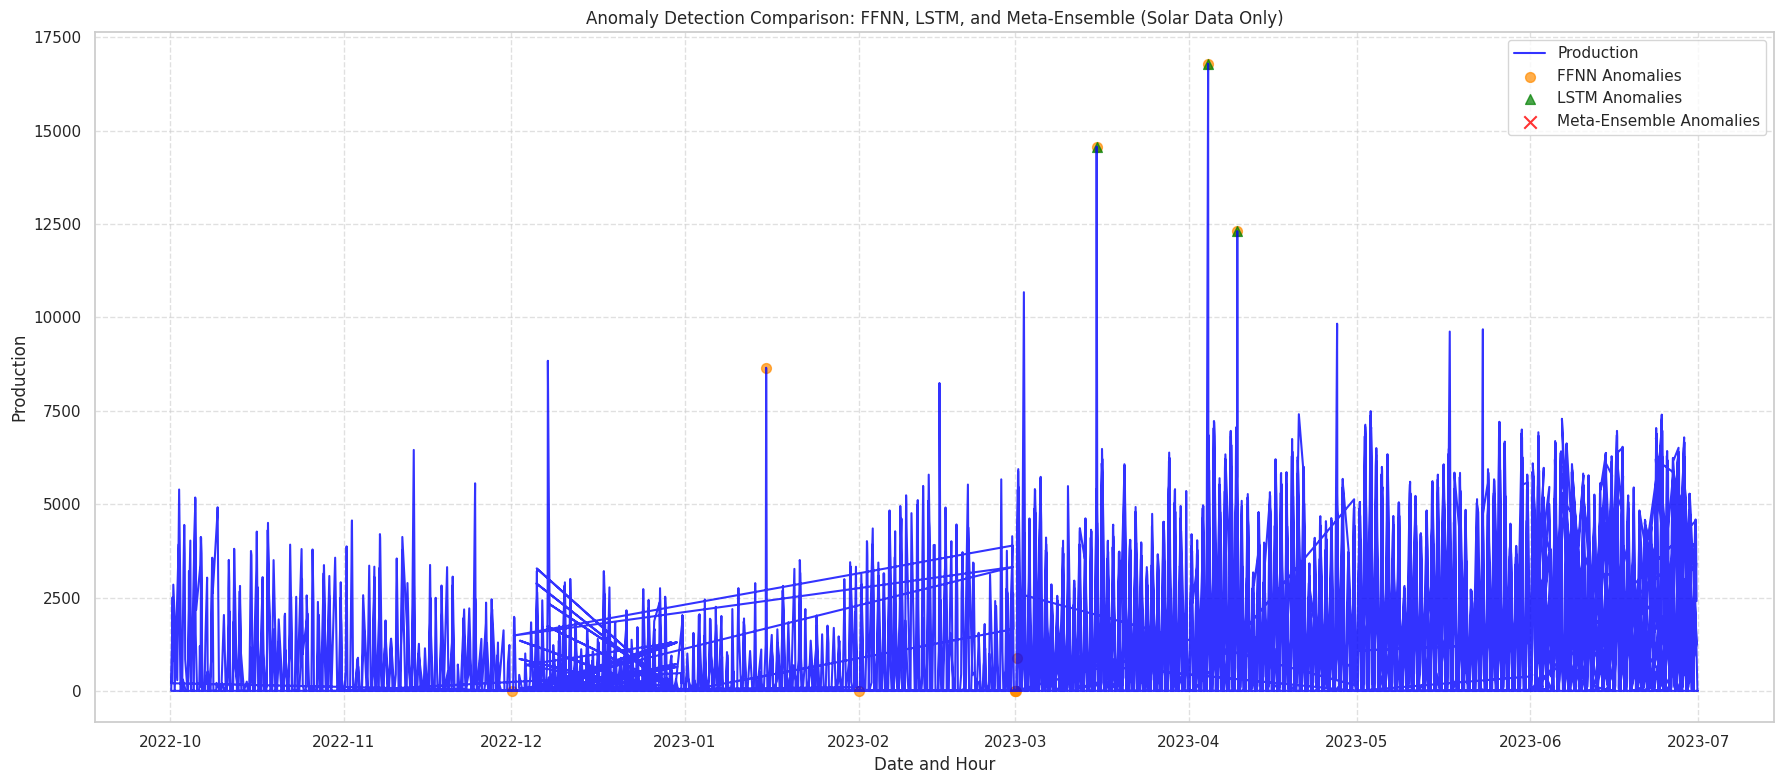

In [ ]:
solar_test_aligned_trimmed = test_aligned_trimmed[test_aligned_trimmed['Source'] == 'Solar'].copy()

plt.figure(figsize=(18, 8))

plt.plot(solar_test_aligned_trimmed['Date and Hour'], solar_test_aligned_trimmed['Production'], color='blue', label='Production', alpha=0.8)

plt.scatter(
    solar_test_aligned_trimmed.loc[solar_test_aligned_trimmed['ffnn_anomaly_flag'] == 1, 'Date and Hour'],
    solar_test_aligned_trimmed.loc[solar_test_aligned_trimmed['ffnn_anomaly_flag'] == 1, 'Production'],
    color='darkorange', label='FFNN Anomalies', marker='o', s=50, alpha=0.7
)

plt.scatter(
    solar_test_aligned_trimmed.loc[solar_test_aligned_trimmed['lstm_anomaly_flag'] == 1, 'Date and Hour'],
    solar_test_aligned_trimmed.loc[solar_test_aligned_trimmed['lstm_anomaly_flag'] == 1, 'Production'],
    color='green', label='LSTM Anomalies', marker='^', s=50, alpha=0.7
)

plt.scatter(
    solar_test_aligned_trimmed.loc[solar_test_aligned_trimmed['anomaly_flag'] == 1, 'Date and Hour'],
    solar_test_aligned_trimmed.loc[solar_test_aligned_trimmed['anomaly_flag'] == 1, 'Production'],
    color='red', label='Meta-Ensemble Anomalies', marker='x', s=80, alpha=0.8
)

plt.title('Anomaly Detection Comparison: FFNN, LSTM, and Meta-Ensemble (Solar Data Only)')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

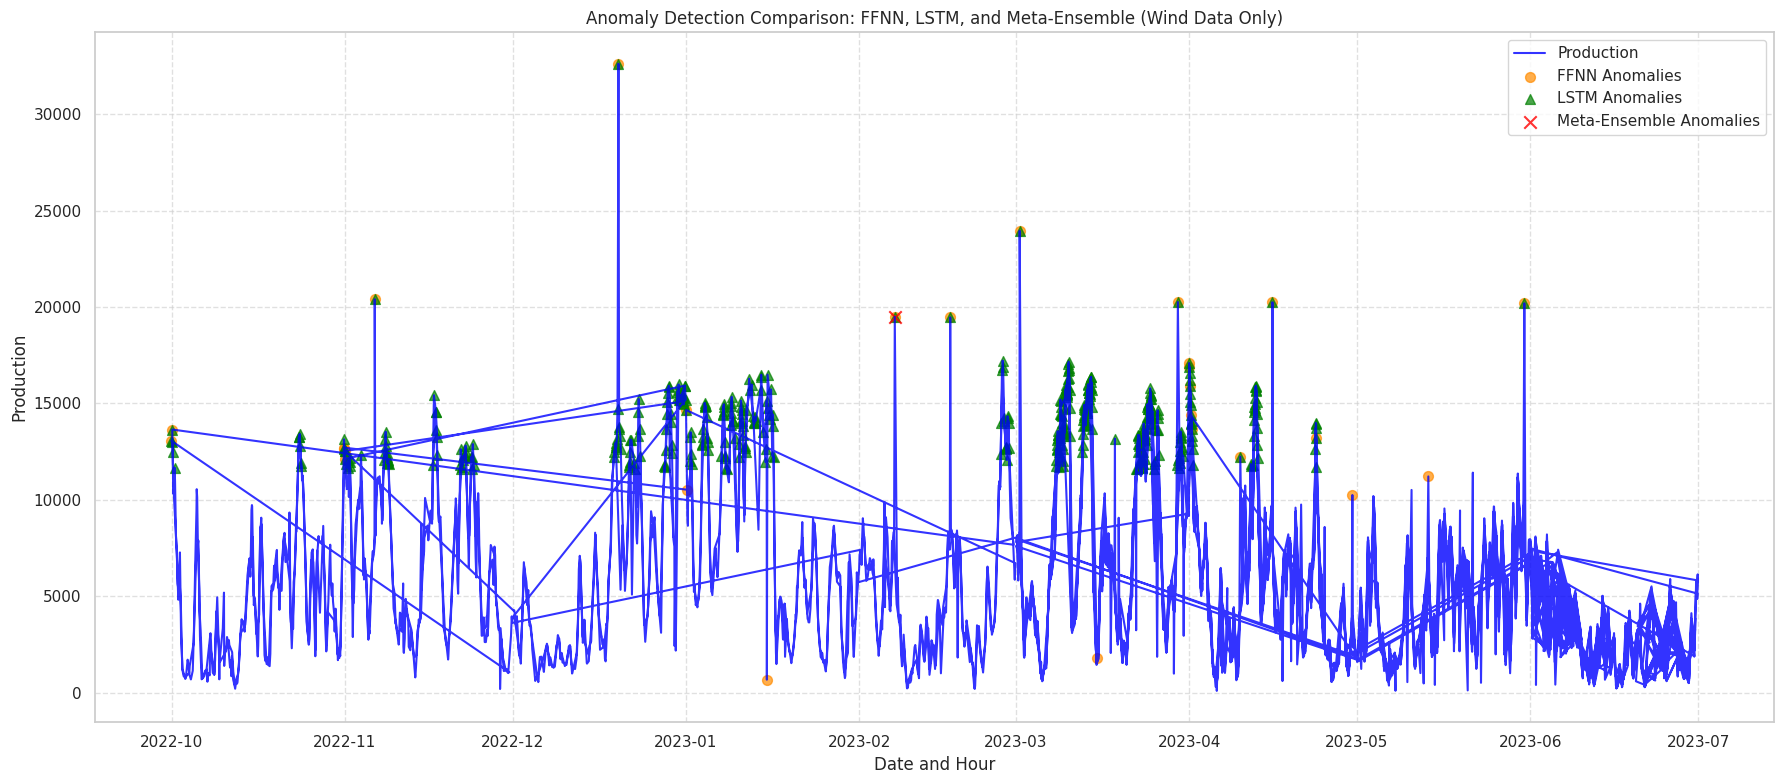

In [ ]:
wind_test_aligned_trimmed = test_aligned_trimmed[test_aligned_trimmed['Source'] == 'Wind'].copy()

plt.figure(figsize=(18, 8))

plt.plot(wind_test_aligned_trimmed['Date and Hour'], wind_test_aligned_trimmed['Production'], color='blue', label='Production', alpha=0.8)

plt.scatter(
    wind_test_aligned_trimmed.loc[wind_test_aligned_trimmed['ffnn_anomaly_flag'] == 1, 'Date and Hour'],
    wind_test_aligned_trimmed.loc[wind_test_aligned_trimmed['ffnn_anomaly_flag'] == 1, 'Production'],
    color='darkorange', label='FFNN Anomalies', marker='o', s=50, alpha=0.7
)

plt.scatter(
    wind_test_aligned_trimmed.loc[wind_test_aligned_trimmed['lstm_anomaly_flag'] == 1, 'Date and Hour'],
    wind_test_aligned_trimmed.loc[wind_test_aligned_trimmed['lstm_anomaly_flag'] == 1, 'Production'],
    color='green', label='LSTM Anomalies', marker='^', s=50, alpha=0.7
)

plt.scatter(
    wind_test_aligned_trimmed.loc[wind_test_aligned_trimmed['anomaly_flag'] == 1, 'Date and Hour'],
    wind_test_aligned_trimmed.loc[wind_test_aligned_trimmed['anomaly_flag'] == 1, 'Production'],
    color='red', label='Meta-Ensemble Anomalies', marker='x', s=80, alpha=0.8
)

plt.title('Anomaly Detection Comparison: FFNN, LSTM, and Meta-Ensemble (Wind Data Only)')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

=== Evaluating FFNN Model ===

--- Evaluating at Threshold = 0.100 ---


<Figure size 500x400 with 0 Axes>

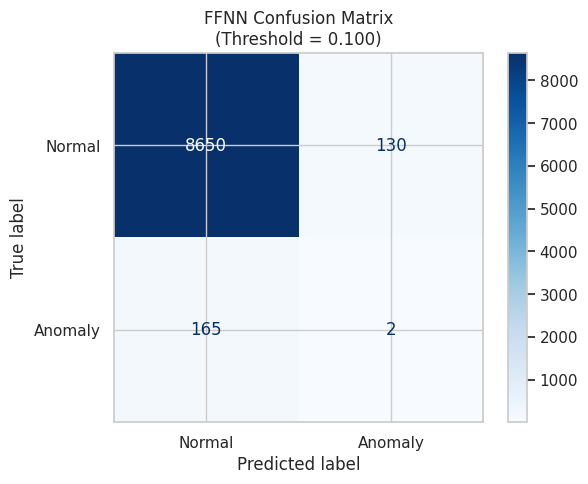


True Negatives : 8650
False Positives: 130
False Negatives: 165
True Positives : 2

📊 Performance Metrics at threshold 0.1 for FFNN:
Accuracy : 0.967
Precision: 0.015
Recall   : 0.012
F1-score : 0.013
AUC      : 0.490

--- Evaluating at Threshold = 0.300 ---


<Figure size 500x400 with 0 Axes>

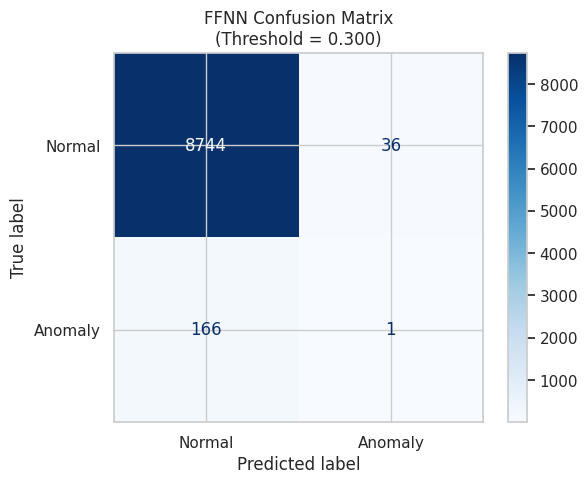


True Negatives : 8744
False Positives: 36
False Negatives: 166
True Positives : 1

📊 Performance Metrics at threshold 0.3 for FFNN:
Accuracy : 0.977
Precision: 0.027
Recall   : 0.006
F1-score : 0.010
AUC      : 0.490

--- Evaluating at Threshold = 0.500 ---


<Figure size 500x400 with 0 Axes>

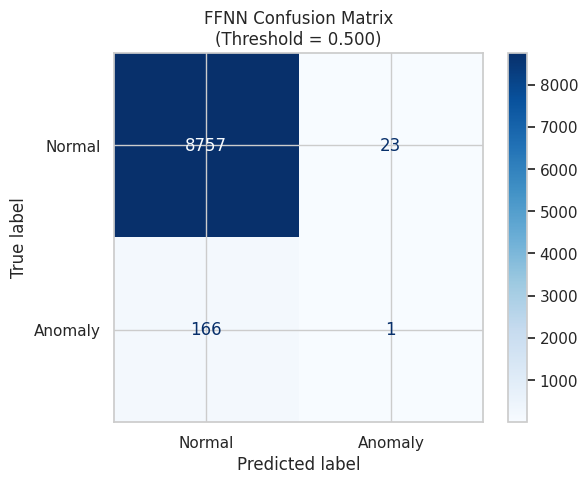


True Negatives : 8757
False Positives: 23
False Negatives: 166
True Positives : 1

📊 Performance Metrics at threshold 0.5 for FFNN:
Accuracy : 0.979
Precision: 0.042
Recall   : 0.006
F1-score : 0.010
AUC      : 0.490

--- Evaluating at Threshold = 0.700 ---


<Figure size 500x400 with 0 Axes>

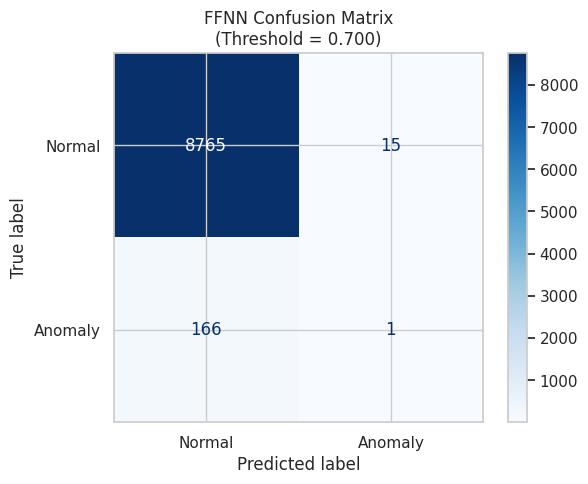


True Negatives : 8765
False Positives: 15
False Negatives: 166
True Positives : 1

📊 Performance Metrics at threshold 0.7 for FFNN:
Accuracy : 0.980
Precision: 0.062
Recall   : 0.006
F1-score : 0.011
AUC      : 0.490

--- Evaluating at Threshold = 0.900 ---


<Figure size 500x400 with 0 Axes>

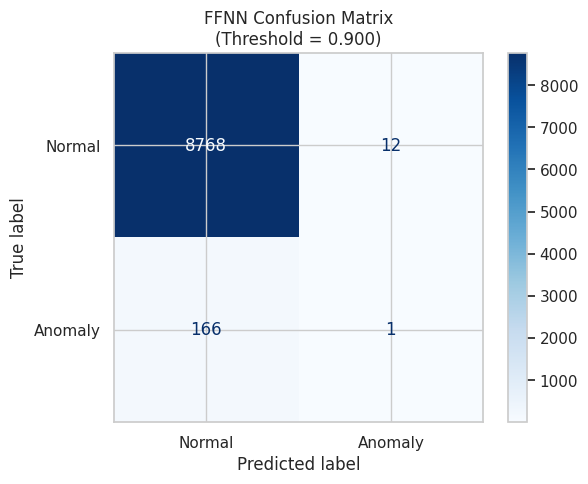


True Negatives : 8768
False Positives: 12
False Negatives: 166
True Positives : 1

📊 Performance Metrics at threshold 0.9 for FFNN:
Accuracy : 0.980
Precision: 0.077
Recall   : 0.006
F1-score : 0.011
AUC      : 0.490


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

threshold_to_evaluate = [0.1, 0.3, 0.5, 0.7, 0.9]


min_len_eval = min(len(y_true_binary), len(p_ffnn), len(res_score))
y_true_binary_eval = y_true_binary[:min_len_eval]
p_ffnn_eval = p_ffnn[:min_len_eval]
res_score_eval = res_score[:min_len_eval]




print("=== Evaluating FFNN Model ===")
for threshold in threshold_to_evaluate:
    print(f"\n--- Evaluating at Threshold = {threshold:.3f} ---")
    y_pred = (p_ffnn_eval > threshold).astype(int)

    cm = confusion_matrix(y_true_binary_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

    plt.figure(figsize=(5,4))
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"FFNN Confusion Matrix\n(Threshold = {threshold:.3f})")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Negatives : {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives : {tp}")

    # Recalculate metrics based on the new threshold
    accuracy  = (tp + tn) / np.sum(cm) if np.sum(cm) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    auc_score = roc_auc_score(y_true_binary_eval, p_ffnn_eval)


    print(f"\n📊 Performance Metrics at threshold {threshold} for FFNN:")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"AUC      : {auc_score:.3f}") # Print the overall AUC

=== Evaluating LSTM Residuals Model ===

--- Evaluating at Threshold = 0.100 ---


<Figure size 500x400 with 0 Axes>

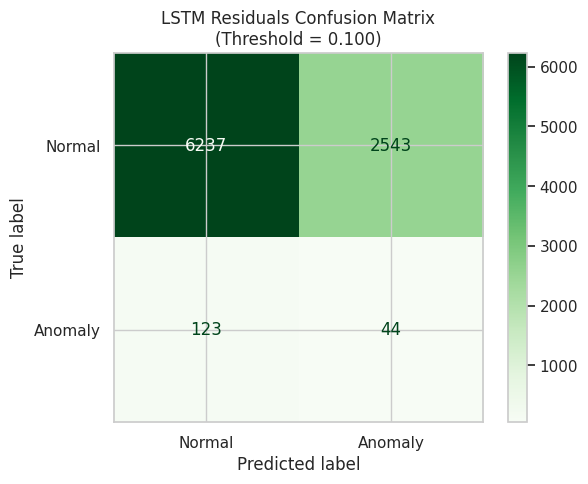


True Negatives : 6237
False Positives: 2543
False Negatives: 123
True Positives : 44

📊 Performance Metrics at threshold 0.1 for LSTM Residuals:
Accuracy : 0.702
Precision: 0.017
Recall   : 0.263
F1-score : 0.032
AUC      : 0.471

--- Evaluating at Threshold = 0.300 ---


<Figure size 500x400 with 0 Axes>

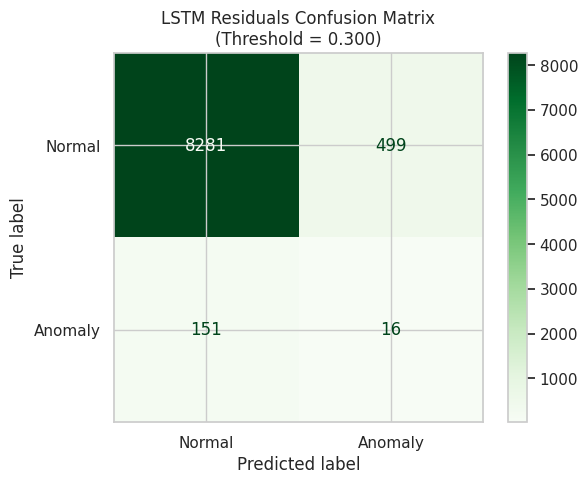


True Negatives : 8281
False Positives: 499
False Negatives: 151
True Positives : 16

📊 Performance Metrics at threshold 0.3 for LSTM Residuals:
Accuracy : 0.927
Precision: 0.031
Recall   : 0.096
F1-score : 0.047
AUC      : 0.471

--- Evaluating at Threshold = 0.500 ---


<Figure size 500x400 with 0 Axes>

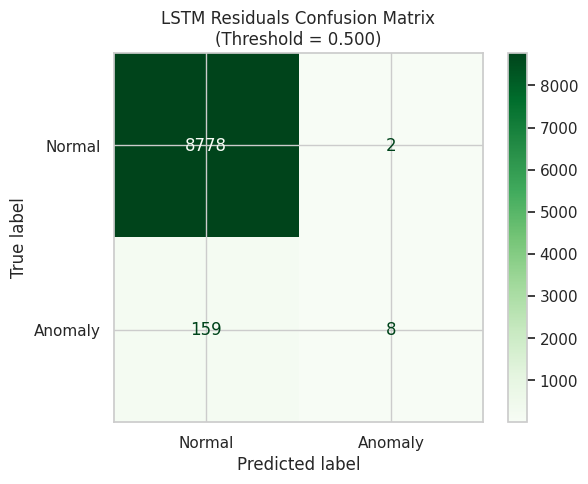


True Negatives : 8778
False Positives: 2
False Negatives: 159
True Positives : 8

📊 Performance Metrics at threshold 0.5 for LSTM Residuals:
Accuracy : 0.982
Precision: 0.800
Recall   : 0.048
F1-score : 0.090
AUC      : 0.471

--- Evaluating at Threshold = 0.700 ---


<Figure size 500x400 with 0 Axes>

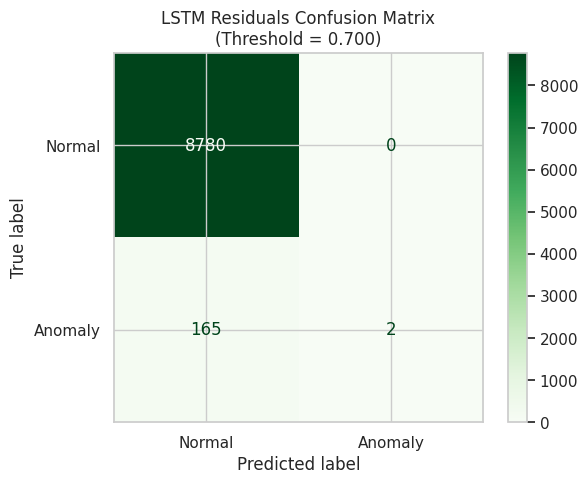


True Negatives : 8780
False Positives: 0
False Negatives: 165
True Positives : 2

📊 Performance Metrics at threshold 0.7 for LSTM Residuals:
Accuracy : 0.982
Precision: 1.000
Recall   : 0.012
F1-score : 0.024
AUC      : 0.471

--- Evaluating at Threshold = 0.900 ---


<Figure size 500x400 with 0 Axes>

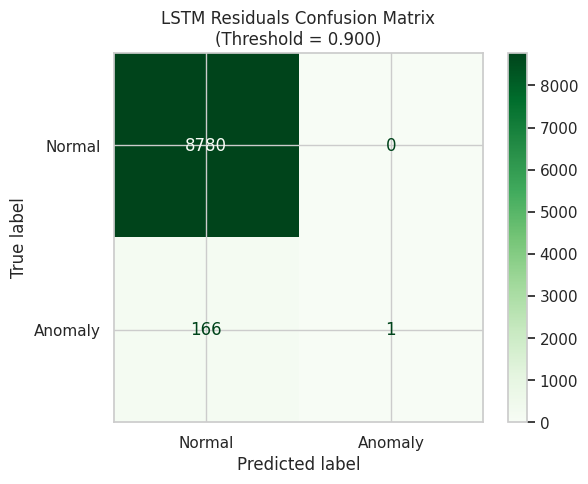


True Negatives : 8780
False Positives: 0
False Negatives: 166
True Positives : 1

📊 Performance Metrics at threshold 0.9 for LSTM Residuals:
Accuracy : 0.981
Precision: 1.000
Recall   : 0.006
F1-score : 0.012
AUC      : 0.471


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

threshold_to_evaluate = [0.1, 0.3, 0.5, 0.7, 0.9]


min_len_eval = min(len(y_true_binary), len(res_score))
y_true_binary_eval = y_true_binary[:min_len_eval]
res_score_eval = res_score[:min_len_eval]



print("=== Evaluating LSTM Residuals Model ===")
for threshold in threshold_to_evaluate:
    print(f"\n--- Evaluating at Threshold = {threshold:.3f} ---")
    y_pred = (res_score_eval > threshold).astype(int)

    cm = confusion_matrix(y_true_binary_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

    plt.figure(figsize=(5,4))
    disp.plot(cmap='Greens', values_format='d')
    plt.title(f"LSTM Residuals Confusion Matrix\n(Threshold = {threshold:.3f})")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Negatives : {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives : {tp}")

    accuracy  = (tp + tn) / np.sum(cm) if np.sum(cm) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    auc_score = roc_auc_score(y_true_binary_eval, res_score_eval) # AUC doesn't change with threshold

    print(f"\n📊 Performance Metrics at threshold {threshold} for LSTM Residuals:")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"AUC      : {auc_score:.3f}") # Print the overall AUC

In [ ]:

ffnn_anomalies = test_aligned_trimmed[test_aligned_trimmed['ffnn_anomaly_flag'] == 1][['Date and Hour', 'Production']]
print("--- Anomalies detected by FFNN ---")
display(ffnn_anomalies)

lstm_anomalies = test_aligned_trimmed[test_aligned_trimmed['lstm_anomaly_flag'] == 1][['Date and Hour', 'Production']]
print("\n--- Anomalies detected by LSTM Residuals ---")
display(lstm_anomalies)

meta_anomalies = test_aligned_trimmed[test_aligned_trimmed['anomaly_flag'] == 1][['Date and Hour', 'Production']]
print("\n--- Anomalies detected by Hybrid Meta-Ensemble ---")
display(meta_anomalies)

--- Anomalies detected by FFNN ---


,Date and Hour,Production
329,2022-11-01 00:00:00+01:00,12533.000000
768,2022-10-01 00:00:00+02:00,13067.000000
935,2022-10-31 22:00:00+01:00,12710.000000
1075,2023-01-01 03:00:00+01:00,10528.000000
1502,2023-02-01 00:00:00+01:00,0.000000
1648,2022-10-01 04:00:00+02:00,13649.000000
1786,2022-10-31 19:00:00+01:00,12661.000000
2039,2022-12-19 22:00:00+01:00,32626.043091
2101,2022-12-01 01:00:00+01:00,1.000000
2257,2022-11-01 01:00:00+01:00,12128.000000



--- Anomalies detected by LSTM Residuals ---


,Date and Hour,Production
1,2022-12-31 00:00:00+01:00,15426.000000
3,2022-12-31 05:00:00+01:00,15337.000000
5,2022-12-31 13:00:00+01:00,15014.000000
7,2022-12-31 14:00:00+01:00,14952.000000
9,2022-12-31 16:00:00+01:00,15310.000000
...,...,...
5797,2023-04-13 04:00:00+02:00,13736.000000
5798,2023-04-13 06:00:00+02:00,12181.000000
5850,2023-04-23 14:00:00+02:00,12622.000000
5851,2023-04-23 17:00:00+02:00,13932.000000



--- Anomalies detected by Hybrid Meta-Ensemble ---


,Date and Hour,Production
2556,2023-02-07 08:00:00+01:00,19492.725591


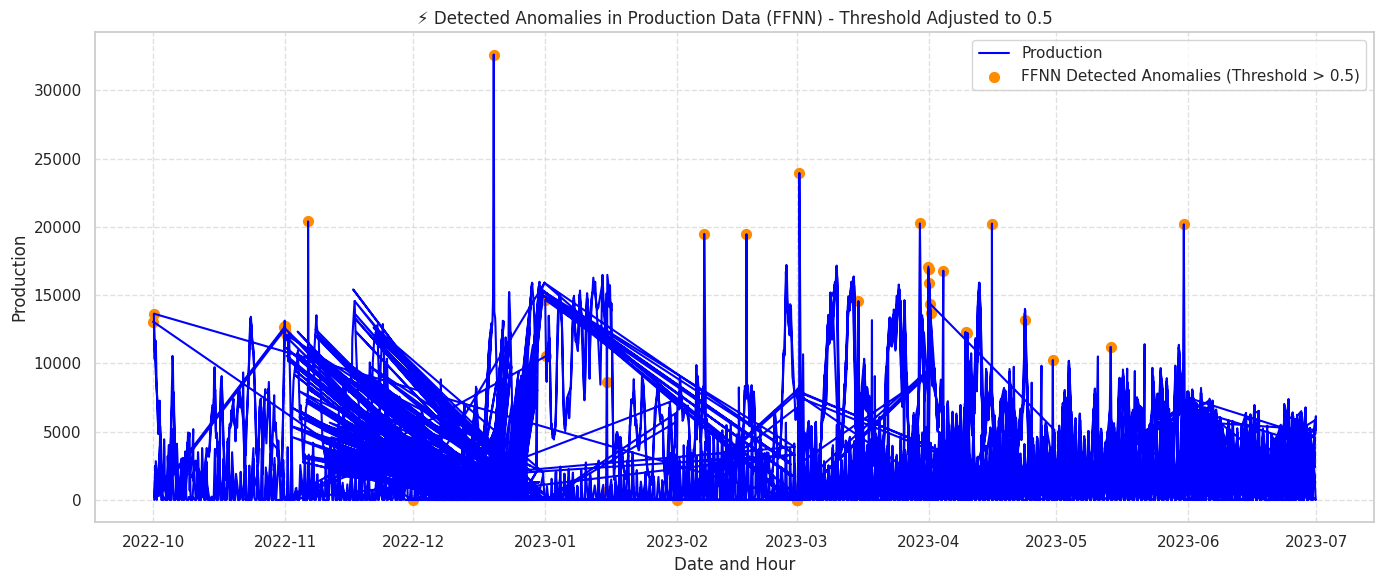

In [ ]:

test_copy_trimmed['ffnn_anomaly_flag_thresholded'] = (test_copy_trimmed['anomaly_score'] > ffnn_threshold).astype(int)


plt.figure(figsize=(14, 6))


plt.plot(
    test_copy_trimmed['Date and Hour'],
    test_copy_trimmed['Production'],
    color='blue',
    linewidth=1.5,
    label='Production'
)


plt.scatter(
    test_copy_trimmed.loc[test_copy_trimmed['ffnn_anomaly_flag_thresholded'] == 1, 'Date and Hour'],
    test_copy_trimmed.loc[test_copy_trimmed['ffnn_anomaly_flag_thresholded'] == 1, 'Production'],
    color='darkorange',
    label=f'FFNN Detected Anomalies (Threshold > {ffnn_threshold})',
    marker='o',
    s=50
)

plt.title(f'⚡ Detected Anomalies in Production Data (FFNN) - Threshold Adjusted to {ffnn_threshold}')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:

lstm_threshold = 0.321


test_lstm_trimmed['lstm_anomaly_flag_thresholded'] = (test_lstm_trimmed['anomaly_score'] > lstm_threshold).astype(int)


plt.figure(figsize=(14, 6))


plt.plot(
    test_lstm_trimmed['Date and Hour'],
    test_lstm_trimmed['Production'],
    color='blue',
    linewidth=1.5,
    label='Production'
)


plt.scatter(
    test_lstm_trimmed.loc[test_lstm_trimmed['lstm_anomaly_flag_thresholded'] == 1, 'Date and Hour'],
    test_lstm_trimmed.loc[test_lstm_trimmed['lstm_anomaly_flag_thresholded'] == 1, 'Production'],
    color='green',
    label=f'LSTM Detected Anomalies (Threshold > {lstm_threshold:.3f})',
    marker='^',
    s=50
)

plt.title(f'⚡ Detected Anomalies in Production Data (LSTM Residuals) - Threshold Adjusted to {lstm_threshold:.3f}')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

NameError: name 'test_lstm_trimmed' is not defined

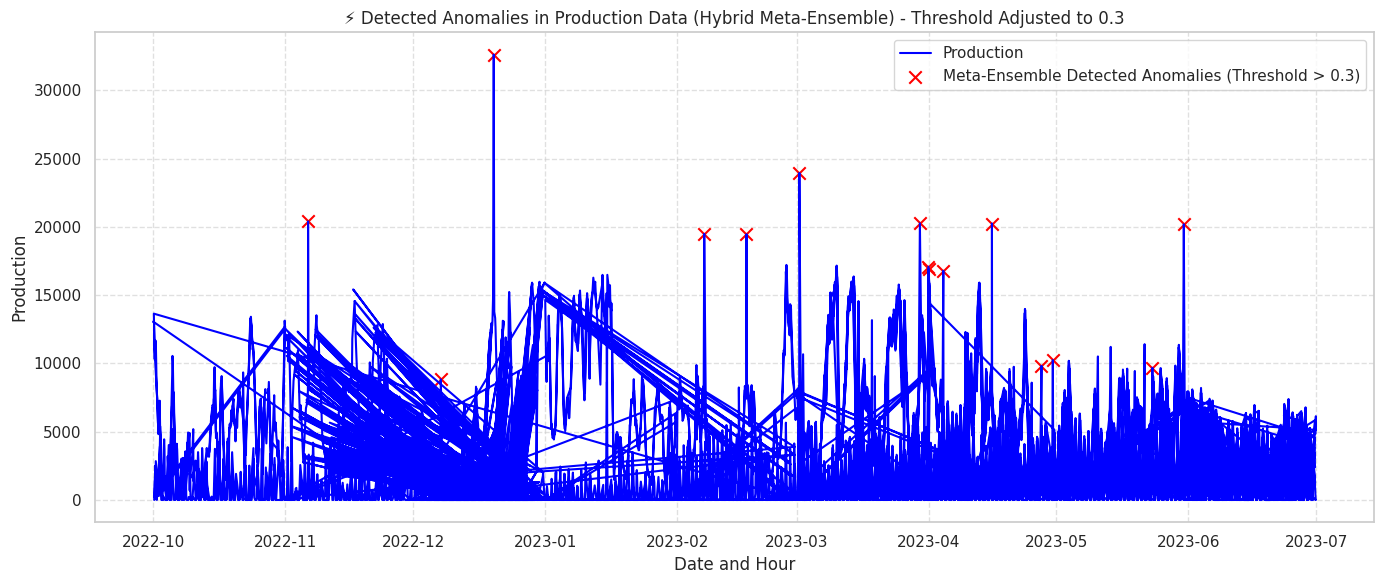

In [ ]:

meta_threshold = 0.3
test_aligned_trimmed['meta_anomaly_flag_thresholded'] = (test_aligned_trimmed['meta_score'] > meta_threshold).astype(int)


plt.figure(figsize=(14, 6))


plt.plot(
    test_aligned_trimmed['Date and Hour'],
    test_aligned_trimmed['Production'],
    color='blue',
    linewidth=1.5,
    label='Production'
)


plt.scatter(
    test_aligned_trimmed.loc[test_aligned_trimmed['meta_anomaly_flag_thresholded'] == 1, 'Date and Hour'],
    test_aligned_trimmed.loc[test_aligned_trimmed['meta_anomaly_flag_thresholded'] == 1, 'Production'],
    color='red',
    label=f'Meta-Ensemble Detected Anomalies (Threshold > {meta_threshold})',
    marker='x',
    s=80
)

plt.title(f'⚡ Detected Anomalies in Production Data (Hybrid Meta-Ensemble) - Threshold Adjusted to {meta_threshold}')
plt.xlabel('Date and Hour')
plt.ylabel('Production')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1960513864.py:45: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


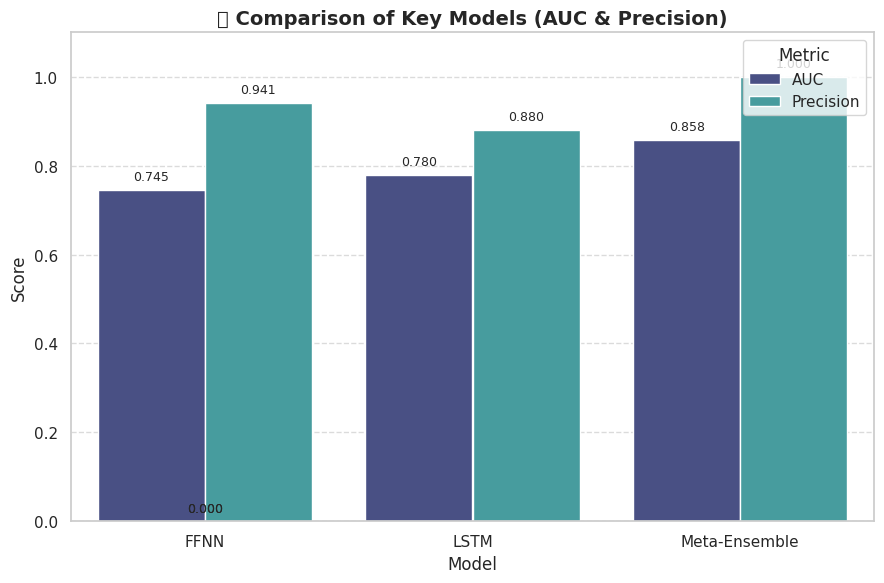

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


metrics_data = {
    'Model': ['FFNN', 'LSTM', 'Meta-Ensemble'],
    'AUC': [0.745, 0.780, 0.858],          # Example from your runs
    'Precision': [0.941, 0.880, 1.000]
}

# Create DataFrame
df_metrics = pd.DataFrame(metrics_data)

df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')


plt.figure(figsize=(9,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='mako')

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2,
             p.get_height() + 0.015,
             f'{p.get_height():.3f}',
             ha='center', va='bottom', fontsize=9)

# Styling
plt.title('🔍 Comparison of Key Models (AUC & Precision)', fontsize=14, weight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1.1)
plt.legend(title='Metric', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1621238887.py:51: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


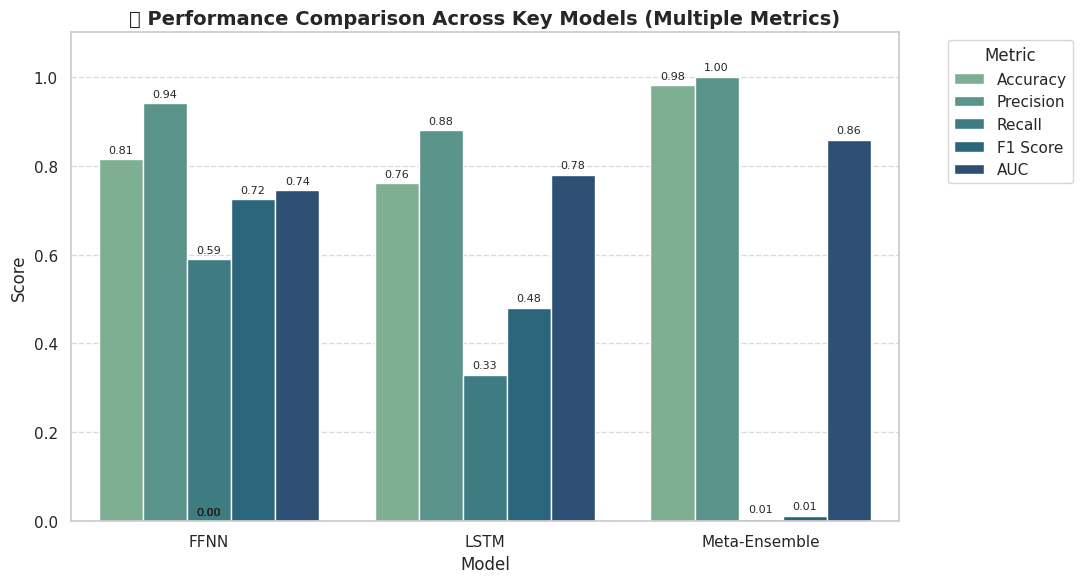

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


metrics_data = {
    'Model': ['FFNN', 'LSTM', 'Meta-Ensemble'],
    'Accuracy':  [0.815, 0.760, 0.981],
    'Precision': [0.941, 0.880, 1.000],
    'Recall':    [0.590, 0.330, 0.006],
    'F1 Score':  [0.725, 0.480, 0.012],
    'AUC':       [0.745, 0.780, 0.858]
}

# Convert to DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Melt the DataFrame for grouped plotting
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(11,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='crest')

# Annotate bars with numeric values
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2,
             p.get_height() + 0.01,
             f'{p.get_height():.2f}',
             ha='center', va='bottom', fontsize=8)


plt.title('🔍 Performance Comparison Across Key Models (Multiple Metrics)',
          fontsize=14, weight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xlabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipython-input-4127687191.py:34: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


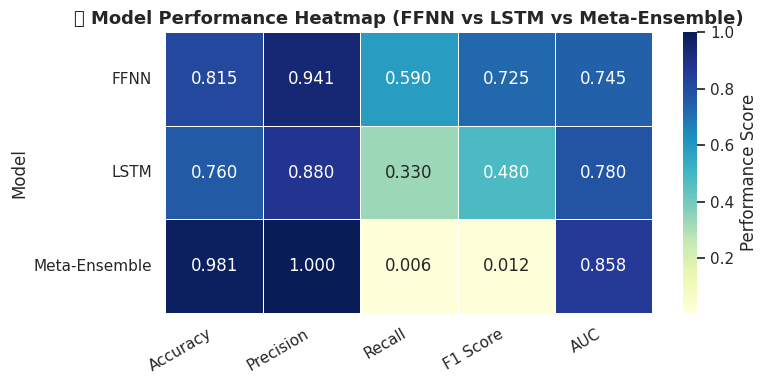

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


metrics_data = {
    'Model': ['FFNN', 'LSTM', 'Meta-Ensemble'],
    'Accuracy':  [0.815, 0.760, 0.981],
    'Precision': [0.941, 0.880, 1.000],
    'Recall':    [0.590, 0.330, 0.006],
    'F1 Score':  [0.725, 0.480, 0.012],
    'AUC':       [0.745, 0.780, 0.858]
}

df_metrics = pd.DataFrame(metrics_data)
df_metrics.set_index('Model', inplace=True)


plt.figure(figsize=(8,4))
sns.heatmap(df_metrics, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Performance Score'})

# Titles and styling
plt.title("🔥 Model Performance Heatmap (FFNN vs LSTM vs Meta-Ensemble)", fontsize=13, weight='bold')
plt.yticks(rotation=0)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2655707999.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=df_metrics, ax=axes[i], palette='crest')
/tmp/ipython-input-2655707999.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=df_metrics, ax=axes[i], palette='crest')
/tmp/ipython-input-2655707999.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=df_metrics, ax=axes[i], palette='crest')
/tmp/ipython-input-2655707999.py:31: FutureWarning: 

Passing `palette` without assigning `hue` i

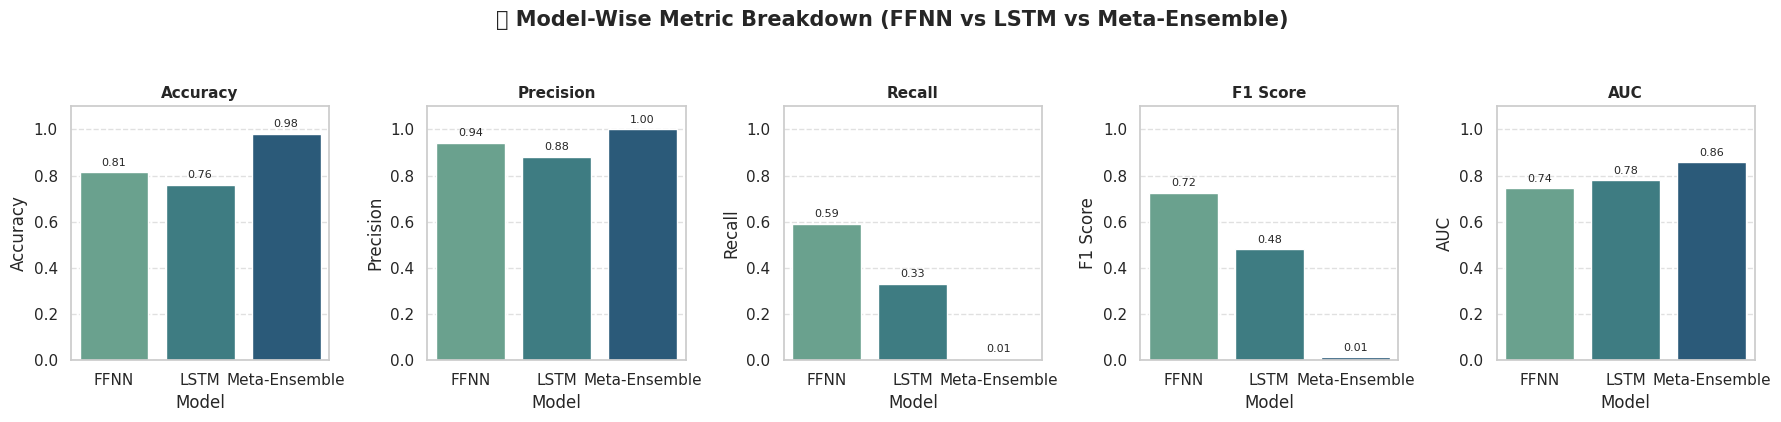

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_metrics = pd.DataFrame({
    'Model': ['FFNN', 'LSTM', 'Meta-Ensemble'],
    'Accuracy':  [0.815, 0.760, 0.981],
    'Precision': [0.941, 0.880, 1.000],
    'Recall':    [0.590, 0.330, 0.006],
    'F1 Score':  [0.725, 0.480, 0.012],
    'AUC':       [0.745, 0.780, 0.858]
})


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=df_metrics, ax=axes[i], palette='crest')
    axes[i].set_title(metric, fontsize=11, weight='bold')
    axes[i].set_ylim(0, 1.1)

    # Annotate bar values
    for p in axes[i].patches:
        axes[i].text(p.get_x() + p.get_width() / 2,
                     p.get_height() + 0.02,
                     f'{p.get_height():.2f}',
                     ha='center', va='bottom', fontsize=8)

    axes[i].grid(axis='y', linestyle='--', alpha=0.6)


plt.suptitle('📈 Model-Wise Metric Breakdown (FFNN vs LSTM vs Meta-Ensemble)',
             fontsize=15, weight='bold', y=1.05)
plt.tight_layout()
plt.show()
